# Telecom Customer Churn Prediction

## I.Introduction

**_What is customer churn?_**

Customer churn occurs when a customer ends their relationship with a company by canceling a subscription or switching to a competitor. It is typically measured using the customer churn rate, which represents the percentage of customers lost over a specific period. This metric is a key indicator of customer satisfaction and overall business health.

**_Why focus on customer churn?_**

The telecommunications sector is a highly competitive market, with annual churn rates ranging from 15% to 25%. Acquiring new customers is also significantly more expensive—about five times the cost of retaining existing ones.
For this reason, it is essential for companies to understand the causes of customer churn so they can reduce it and accurately predict which customers are at high risk of leaving.

**_What does this bring to a company?_**

By forecasting high-risk customers, a company can direct its retention efforts and resources toward the individuals who need them most, in a cost-effective way.
Reducing churn not only protects the company’s market position but also enables growth by allowing more investment in new customer acquisition campaigns, expanding coverage, and strengthening customer loyalty.


### Check Virtual Environment

In [2]:
#List of anaconda virtual environment
! conda env list


# conda environments:
#
                       C:\Users\stanl\.ai-navigator\micromamba\envs\cpu
base                   C:\Users\stanl\anaconda3
DL                     C:\Users\stanl\anaconda3\envs\DL
ML                     C:\Users\stanl\anaconda3\envs\ML
churn                * C:\Users\stanl\anaconda3\envs\churn
deploy                 C:\Users\stanl\anaconda3\envs\deploy



In [3]:
#List of packages of the current virtual environment
! conda list

# packages in environment at C:\Users\stanl\anaconda3\envs\churn:
#
# Name                       Version                Build                  Channel
_openmp_mutex                4.5                    2_gnu                  conda-forge
annotated-doc                0.0.4                  pypi_0                 pypi
annotated-types              0.7.0                  pypi_0                 pypi
anyio                        4.12.1                 pypi_0                 pypi
argon2-cffi                  25.1.0                 py314haa95532_0
argon2-cffi-bindings         25.1.0                 py314h02ab6af_0
asttokens                    3.0.0                  py314haa95532_0
async-lru                    2.0.5                  py314haa95532_0
attrs                        25.4.0                 py314haa95532_2
babel                        2.17.0                 py314haa95532_0
beautifulsoup4               4.14.3                 py314haa95532_0
bleach                       6.3.0            

### Loading Libraries

In [4]:
# Python Useful Libraries
from typing import Union
import warnings
import pickle

#Data Management Libraries
import numpy as np
import pandas as pd

#Data Visualisation Libraries
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

#Machine Learning Libraries
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import make_column_selector, ColumnTransformer
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.feature_selection import VarianceThreshold, RFECV
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, learning_curve, FixedThresholdClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, precision_recall_curve, f1_score, confusion_matrix, classification_report, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

### Loading Data

In [5]:
#Retrieve data from kaggle
df = pd.read_csv('https://github.com/YBIFoundation/Dataset/raw/main/TelecomCustomerChurn.csv')

In [6]:
#Visualise dataframe
df.head()

,customerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Monthly,Yes,Manual,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Manual,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Monthly,Yes,Manual,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Monthly,Yes,Manual,70.70,151.65,Yes


In [7]:
#Dataframe copy
work_df = df.copy()
work_df

,customerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Monthly,Yes,Manual,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Manual,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Monthly,Yes,Manual,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Monthly,Yes,Manual,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Manual,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No,DSL,Yes,...,No,No,No,No,Monthly,Yes,Manual,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Monthly,Yes,Manual,74.40,306.6,Yes


## II.Exploratory Data Analysis

Objective: Reach the best understanding of the dataset to define modelling strategy.

2.1 Shape Analysis

    Identify the target: "Churn".
    Number of line and columns:
        - Rows = 7043.
        - Columns: 21.
    Columns names and types:
        - customerID           object
        - Gender               object
        - SeniorCitizen         int64
        - Partner              object
        - Dependents           object
        - Tenure                int64
        - PhoneService         object
        - MultipleLines        object
        - InternetService      object
        - OnlineSecurity       object
        - OnlineBackup         object
        - DeviceProtection     object
        - TechSupport          object
        - StreamingTV          object
        - StreamingMovies      object
        - Contract             object
        - PaperlessBilling     object
        - PaymentMethod        object
        - MonthlyCharges      float64
        - TotalCharges         object
        - Churn                object

    Missing value: No missing values.


2.2 Background Analysis

    Target Visualisation:
        - No: 73%
        - Yes: 27%
        Close to the estimated annual customer rate of 15-25%.

    Understand the various features:
        - customerID           Client identification number.
        - Gender               Biological sexual organs.
        - SeniorCitizen        Elderly person (65+ years old), especially one who is retired and living on a pension.
        - Partner              A person or other entity that has an official, contractual relationship to share in the profits, losses, and business happenings of a venture.
        - Dependents           A person who relies on another, especially a family member, for financial support.
        - Tenure               The length of time (month) in contract with the company.
        - PhoneService         Mobile or fix line subscription.
        - MultipleLines        More than 1 communication line associate to the subscriber.
        - InternetService      Web line subcripstion.
        - OnlineSecurity       The practice of protecting internet-connected systems and data from cyberattacks, threats, and unauthorized access.
        - OnlineBackup         Rhe process of copying data to a remote, offsite location using the internet, typically to cloud-based servers.
        - DeviceProtection     Refer to securing electronic devices against cyber threats, or coverage for accidental damage, loss, or theft of a physical device.
        - TechSupport          Service provided to registered users/subscribers with help and advice about the company's products.
        - StreamingTV          Distributed digital television content via internet connection.
        - StreamingMovies      Distributed digital movies content via internet connection.
        - Contract             Period of the subscribers recurrent payment, usually monthly or yearly.
        - PaperlessBilling     The process of sending and receiving bills electronically, such as through email or an online account, instead of using traditional paper mail.
        - PaymentMethod        The specific way a customer transfers funds to a business or individual to pay for goods or services.
        - MonthlyCharges       Recurring costs for a service, membership, or subscription that are billed each calendar month.
        - TotalCharges         The whole amount of money owed, which is the sum of all individual costs for goods or services.
        - Churn                Customer churn subcription state.

    Visualise the relation between features and target (Plot/ Histogram / Boxplot):
        - Done.

    NaN Analysis:
        - 11 empty data in "TotalCharges" features.

    Identity the outliers:
        -No Outliers.

2.3 Null Hypothesis (H0)

        Are all the features (numerical and categorical) influence the target output ?

2.4 Initial Conclusion

        "Gender", "Partner", "Dependents", "MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "PaymentMethod", "SeniorCitizen", "Tenure", "MonthlyCharges", "TotalCharges" features validate the various features selection methods and show reel impact on the target ("Churn").


### 2.1 Shape Analysis

In [8]:
#Identify the target
columns_name = work_df.columns
columns_name

Index(['customerID', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'Tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [9]:
#Save the target name
target_name =  columns_name[-1]
print(f"Target name: {target_name}")

Target name: Churn


In [10]:
#Dataframe dimension
work_df.shape

(7043, 21)

In [11]:
#Columns name and types
data_types = work_df.dtypes
print(data_types)

customerID              str
Gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
Tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [12]:
#Column type distribution
data_types.value_counts()

str        18
int64       2
float64     1
Name: count, dtype: int64

In [13]:
#Missing Values
work_df.isna().sum()/df.shape[0]

customerID          0.0
Gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
Tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64

In [14]:
work_df.isnull().sum()

customerID          0
Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

<Axes: >

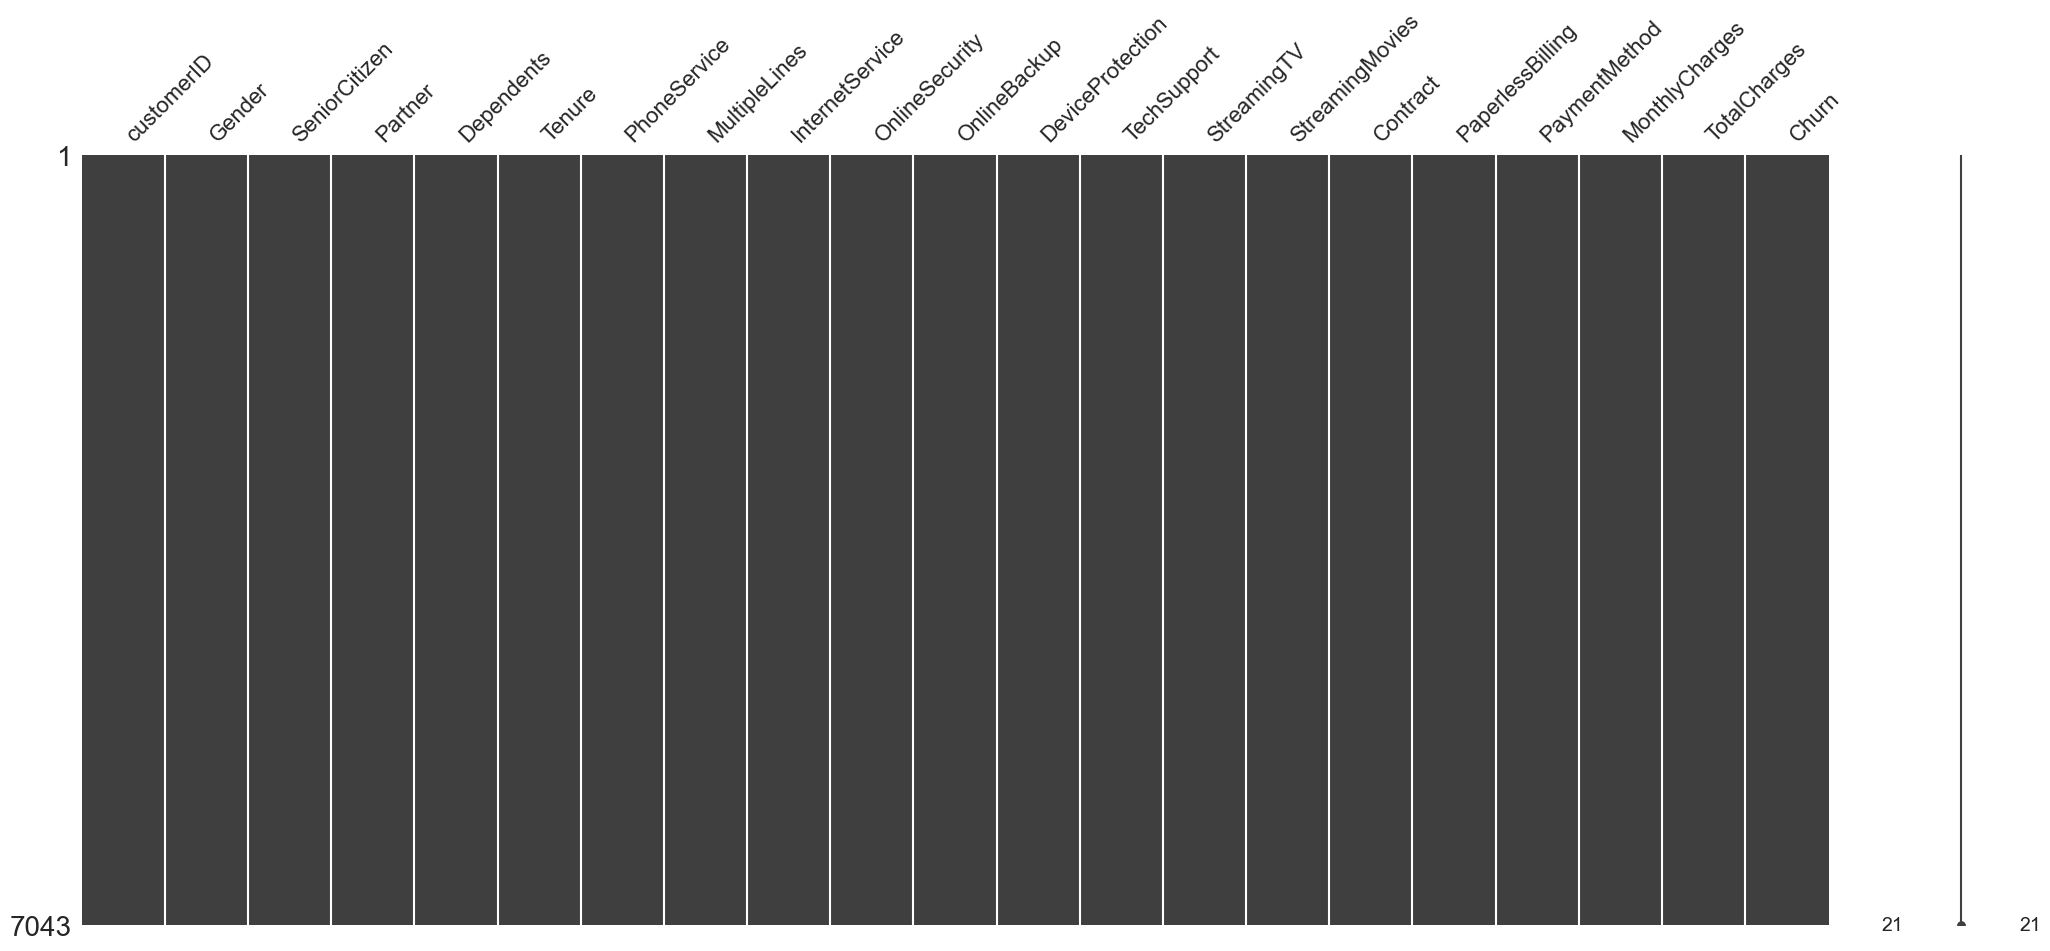

In [15]:
# Visualize missing values as a matrix
msno.matrix(work_df)

In [16]:
#Summarise Shape Analysis
work_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   Gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   Tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### 2.2 Background Analysis

In [17]:
#Target Distribution
sr_target = work_df[target_name]
sr_target.value_counts(normalize= True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

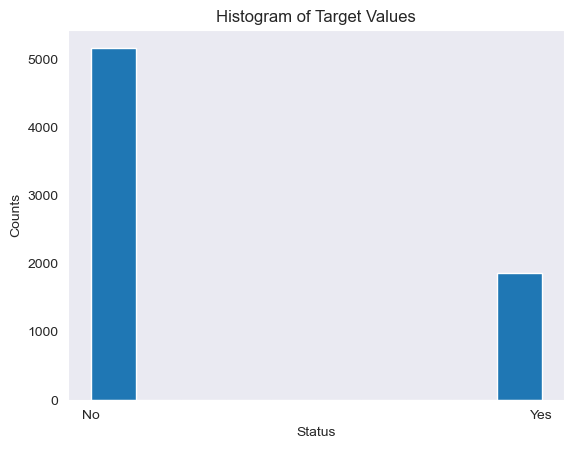

In [18]:
#Target Distribution Visualisation
plt.figure()
sr_target.hist()
plt.xlabel('Status')
plt.ylabel('Counts')
plt.title('Histogram of Target Values')
plt.grid(visible= False)
plt.show()

In [19]:
#Visualise the relation between features and target

#Seperate the columns types
numerical_columns  = work_df.select_dtypes(include= np.number).columns
categorial_columns = work_df.select_dtypes(include= ["object", "string"]).columns

numerical_columns = list(numerical_columns)
categorial_columns = list(categorial_columns)

In [20]:
#Delete the unnecessary feature and target from features
unnecessary_columns = ["customerID", target_name]

for column in unnecessary_columns:
    categorial_columns.remove(column)
categorial_columns

['Gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'TotalCharges']

In [21]:
#Check categorical features value distribution
for col in categorial_columns :
    print(f"{col:-<50} {work_df[col].unique().tolist()}")

Gender-------------------------------------------- ['Female', 'Male']
Partner------------------------------------------- ['Yes', 'No']
Dependents---------------------------------------- ['No', 'Yes']
PhoneService-------------------------------------- ['No', 'Yes']
MultipleLines------------------------------------- ['No', 'Yes']
InternetService----------------------------------- ['DSL', 'Fiber optic', 'No']
OnlineSecurity------------------------------------ ['No', 'Yes']
OnlineBackup-------------------------------------- ['Yes', 'No']
DeviceProtection---------------------------------- ['No', 'Yes']
TechSupport--------------------------------------- ['No', 'Yes']
StreamingTV--------------------------------------- ['No', 'Yes']
StreamingMovies----------------------------------- ['No', 'Yes']
Contract------------------------------------------ ['Monthly', 'One year', 'Two year']
PaperlessBilling---------------------------------- ['Yes', 'No']
PaymentMethod-----------------------------------

In [22]:
#Found empty cell
for col in columns_name:
    print(f"{col} : {work_df[work_df[col] == " "].index}")

customerID : RangeIndex(start=0, stop=0, step=1)
Gender : RangeIndex(start=0, stop=0, step=1)
SeniorCitizen : RangeIndex(start=0, stop=0, step=1)
Partner : RangeIndex(start=0, stop=0, step=1)
Dependents : RangeIndex(start=0, stop=0, step=1)
Tenure : RangeIndex(start=0, stop=0, step=1)
PhoneService : RangeIndex(start=0, stop=0, step=1)
MultipleLines : RangeIndex(start=0, stop=0, step=1)
InternetService : RangeIndex(start=0, stop=0, step=1)
OnlineSecurity : RangeIndex(start=0, stop=0, step=1)
OnlineBackup : RangeIndex(start=0, stop=0, step=1)
DeviceProtection : RangeIndex(start=0, stop=0, step=1)
TechSupport : RangeIndex(start=0, stop=0, step=1)
StreamingTV : RangeIndex(start=0, stop=0, step=1)
StreamingMovies : RangeIndex(start=0, stop=0, step=1)
Contract : RangeIndex(start=0, stop=0, step=1)
PaperlessBilling : RangeIndex(start=0, stop=0, step=1)
PaymentMethod : RangeIndex(start=0, stop=0, step=1)
MonthlyCharges : RangeIndex(start=0, stop=0, step=1)
TotalCharges : Index([488, 753, 936, 

The empty are found inside the "TotalCharges" features.
Delete the missing values (11) rows as its will not affect the dataset.

In [23]:
#Delete empty rows in "TotalCharges"
work_df.drop(labels= work_df[work_df["TotalCharges"] == " "].index, axis= "index", inplace=True)
work_df

,customerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Monthly,Yes,Manual,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Manual,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Monthly,Yes,Manual,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Monthly,Yes,Manual,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Manual,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No,DSL,Yes,...,No,No,No,No,Monthly,Yes,Manual,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Monthly,Yes,Manual,74.40,306.6,Yes


In [24]:
#Convert categorical features into numerical features
work_df["TotalCharges"] = work_df["TotalCharges"].map(lambda x: float(x))
print(f"\"TotalCharge\" types: {work_df["TotalCharges"].dtypes}")

"TotalCharge" types: float64


In [25]:
#Correct the numerical and categorical features list
numerical_columns.append("TotalCharges")
categorial_columns.remove("TotalCharges")

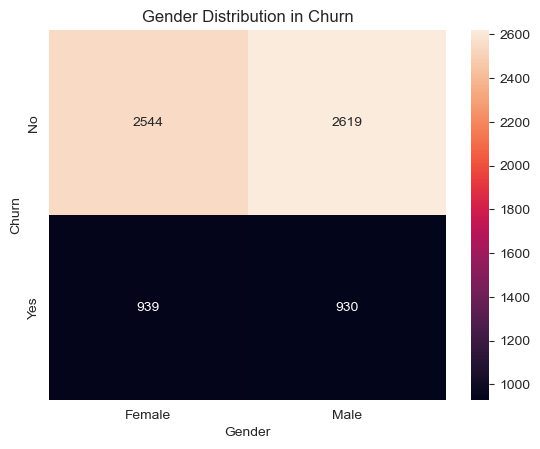

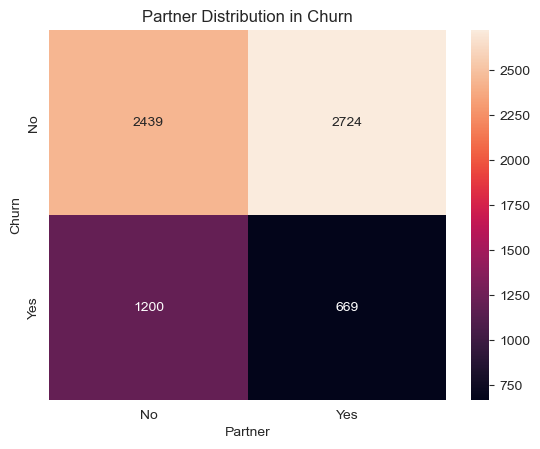

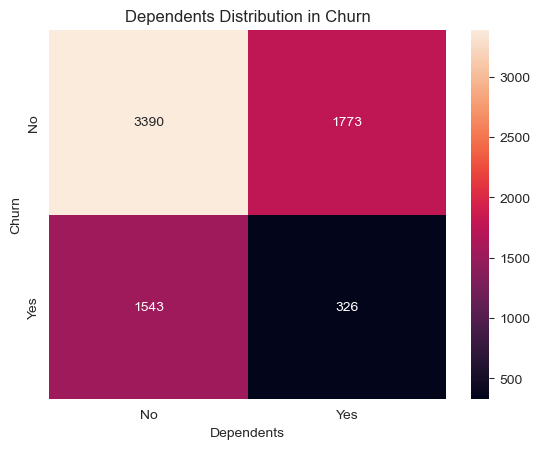

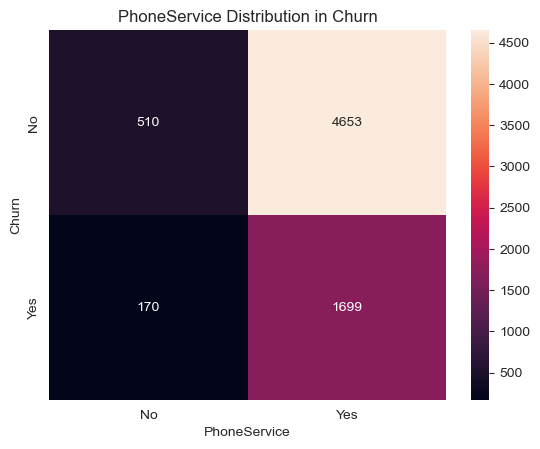

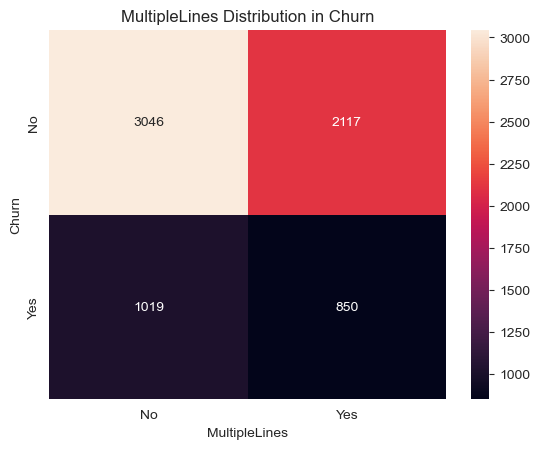

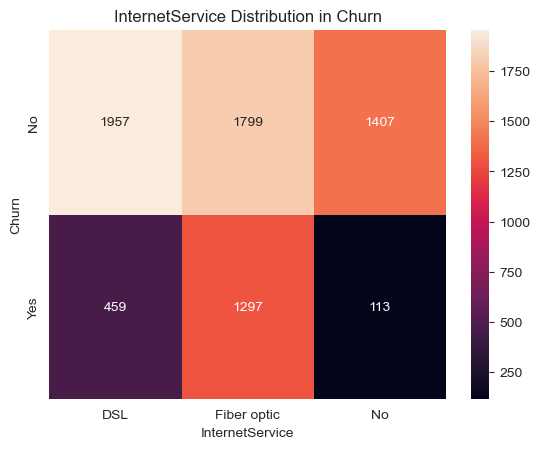

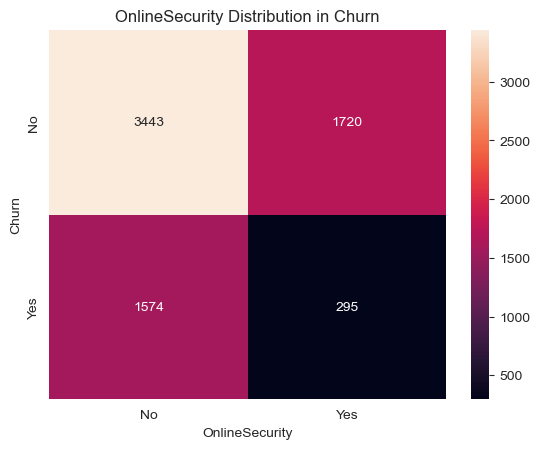

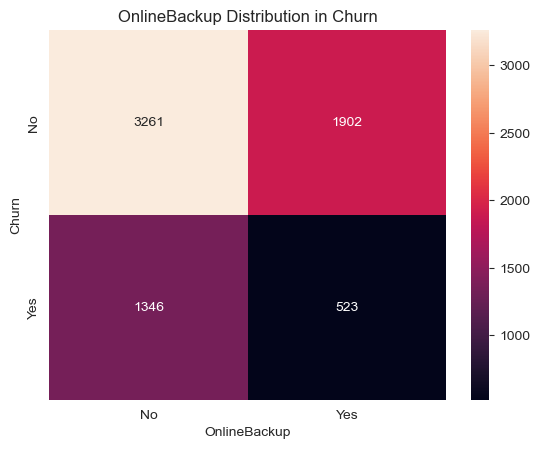

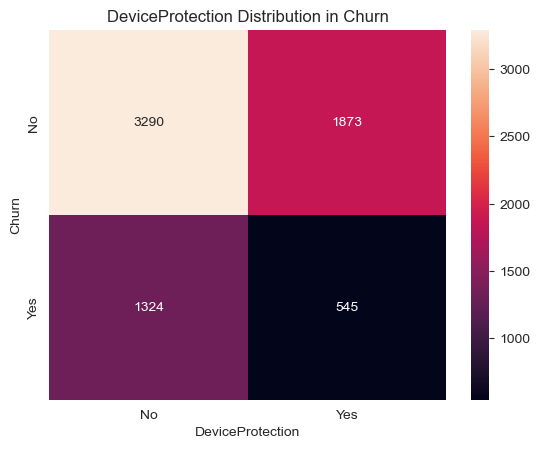

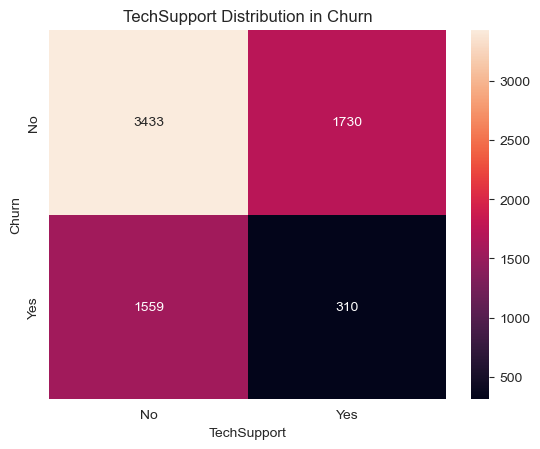

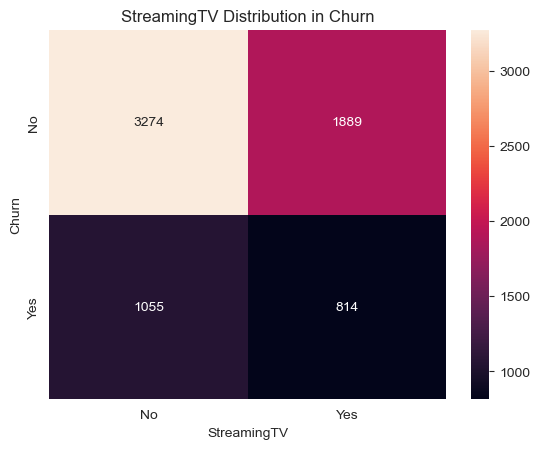

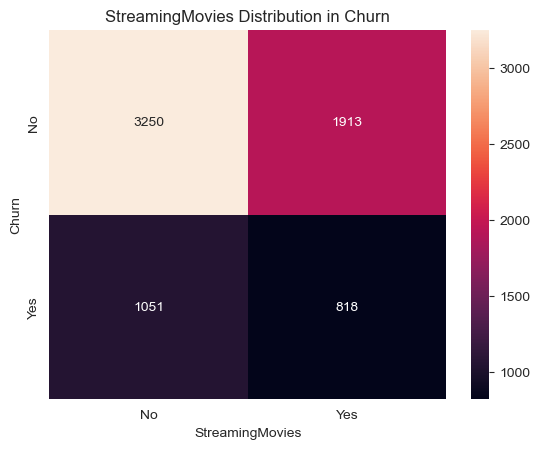

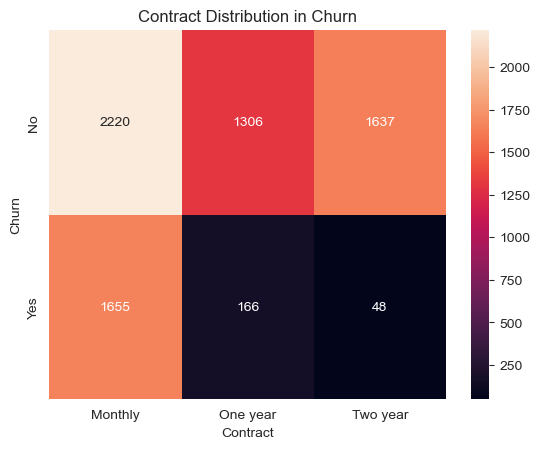

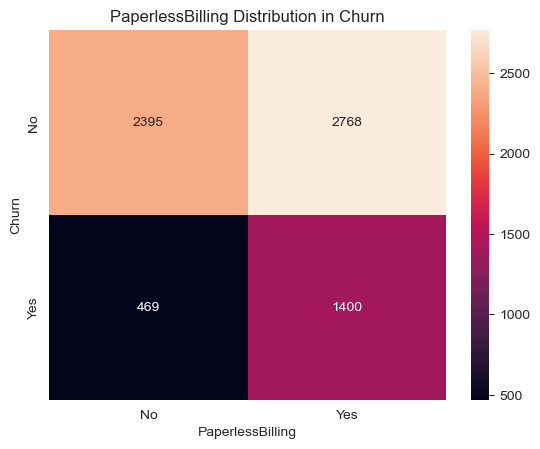

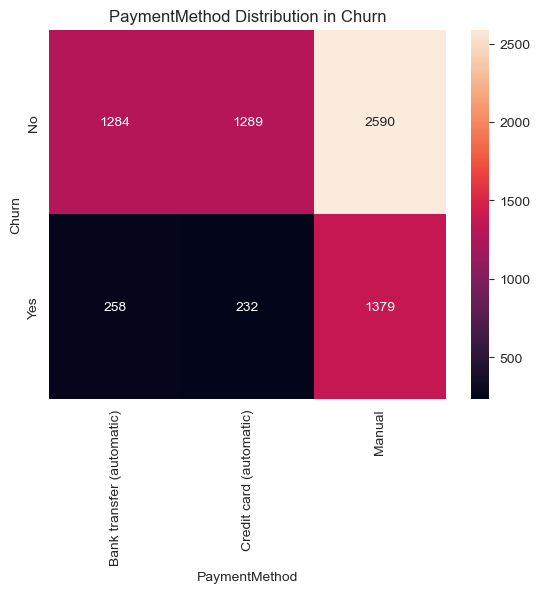

In [26]:
#Visualise the relationship between categorical features and target
for col in categorial_columns:
    plt.figure()
    sns.heatmap(pd.crosstab(work_df[target_name], work_df[col]), annot= True, fmt= 'd')
    plt.title(f"{col} Distribution in {target_name}")
    plt.show()

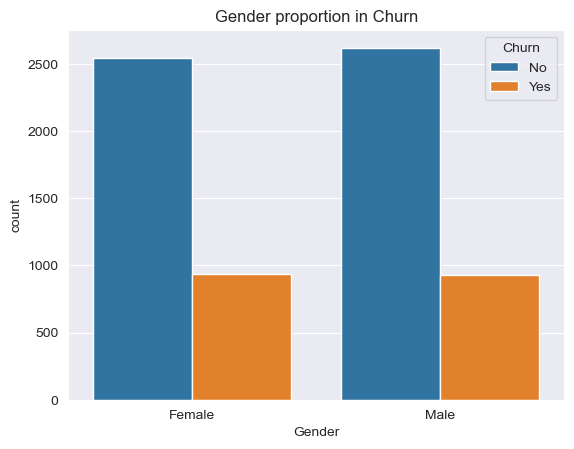

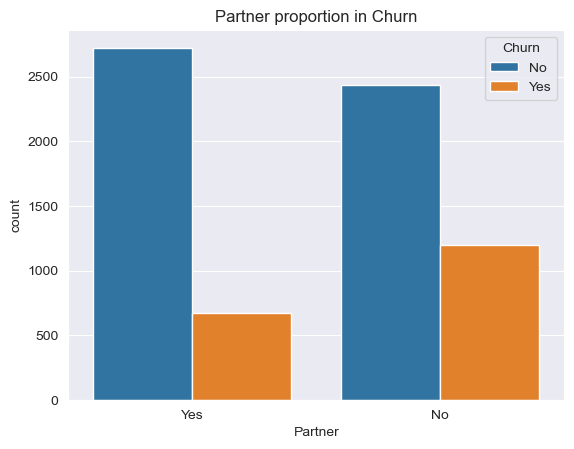

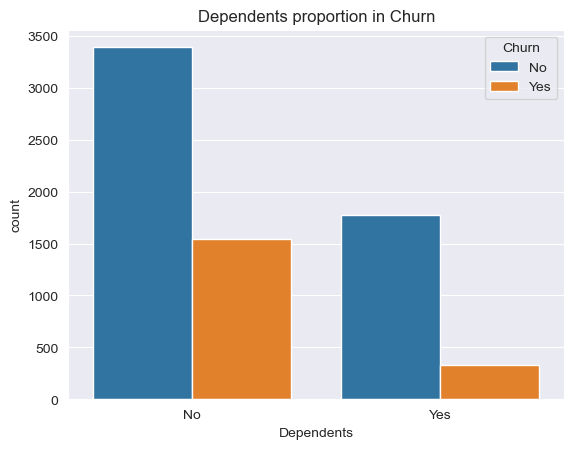

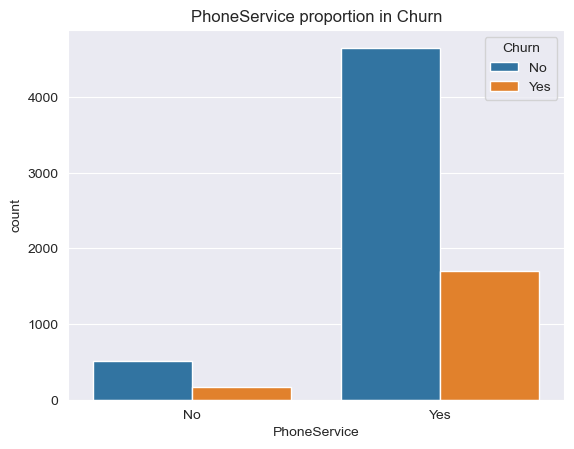

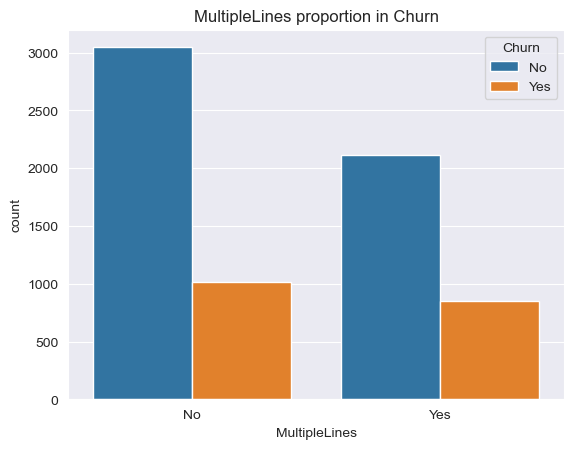

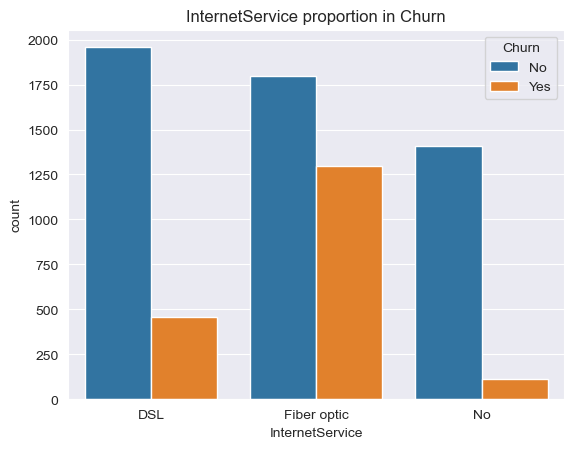

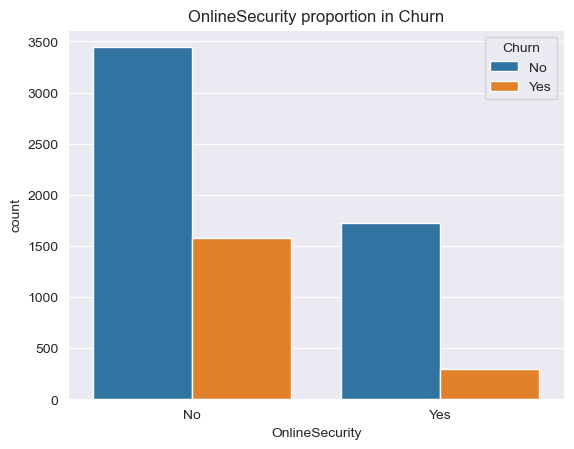

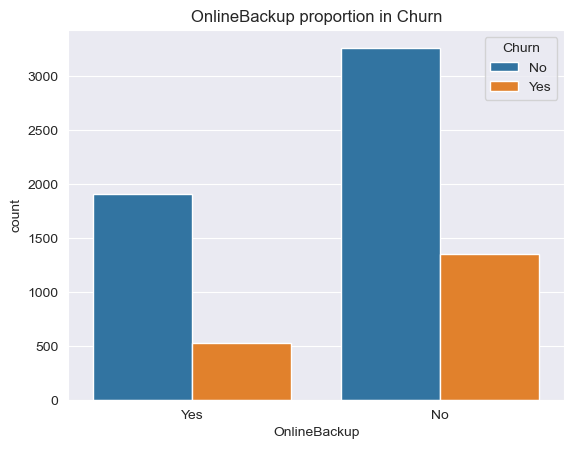

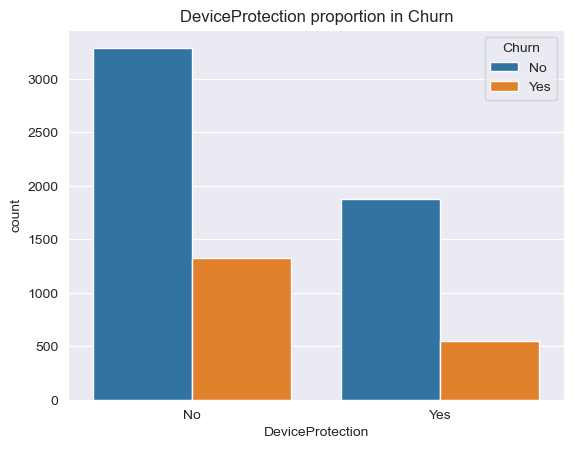

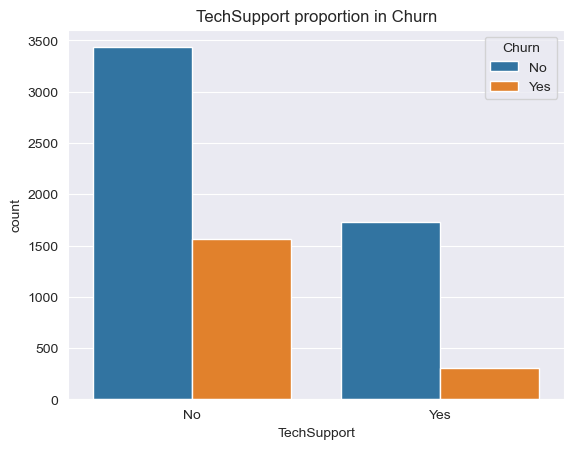

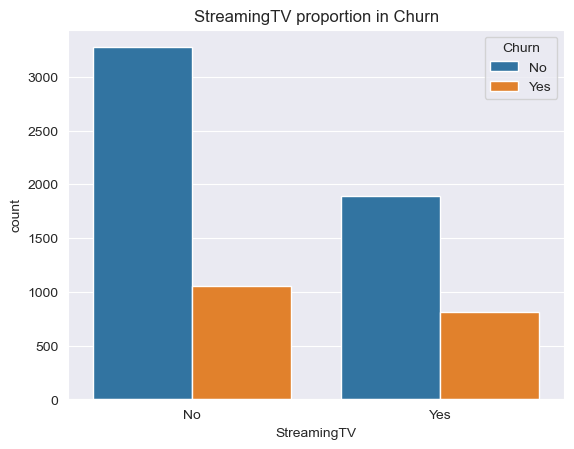

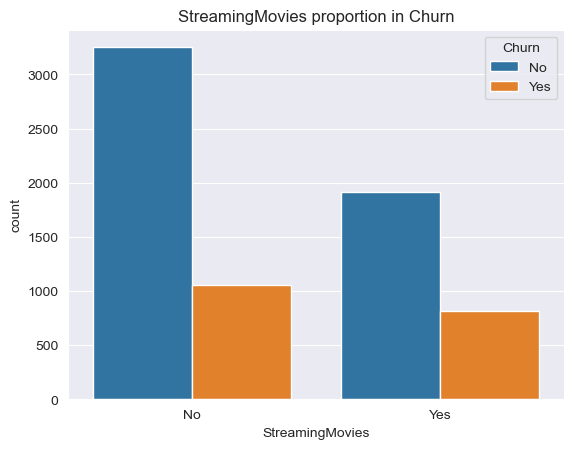

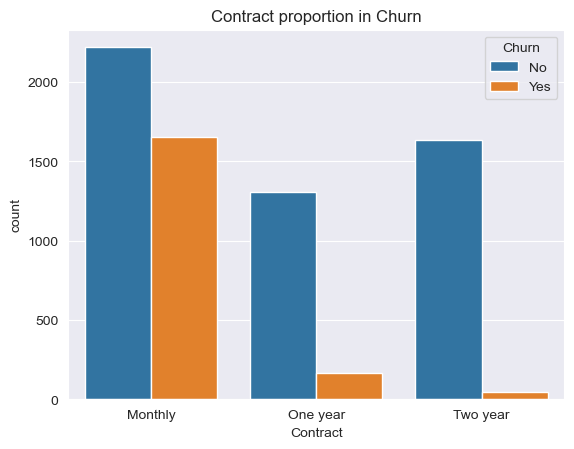

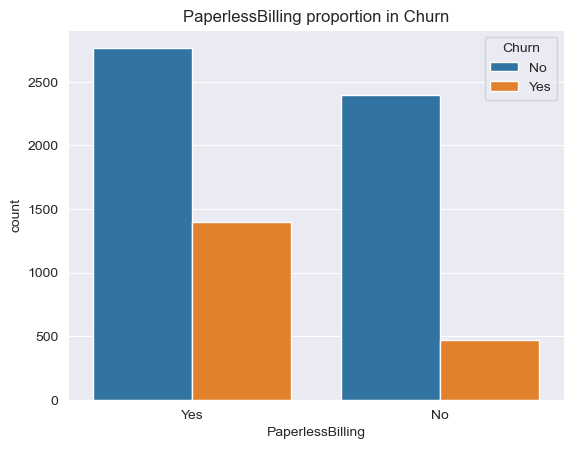

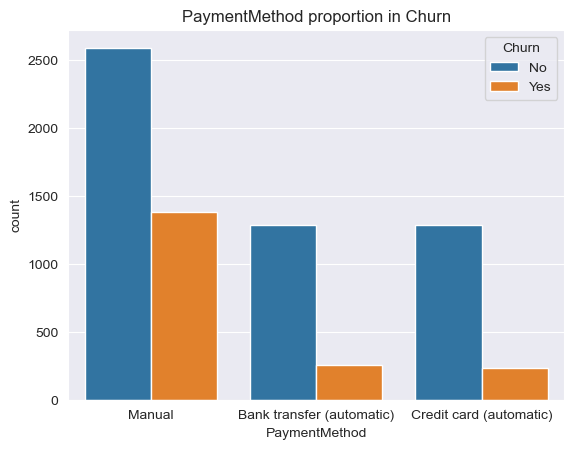

In [27]:
#Clearer representation
for col in categorial_columns:
    plt.figure()
    sns.countplot(data= work_df, x= col, hue= target_name)
    plt.title(f"{col} proportion in {target_name}")
    plt.show()

<Figure size 640x480 with 0 Axes>

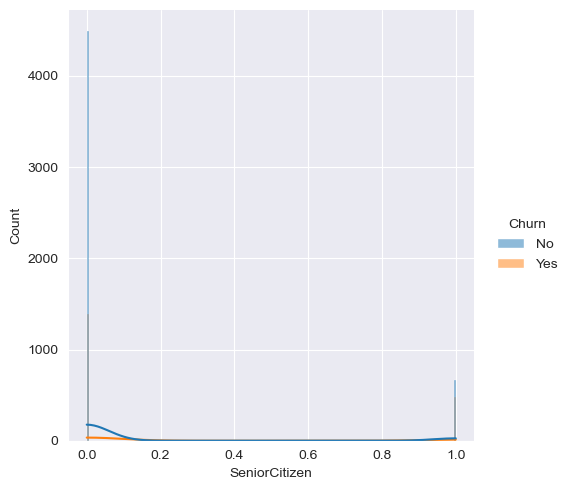

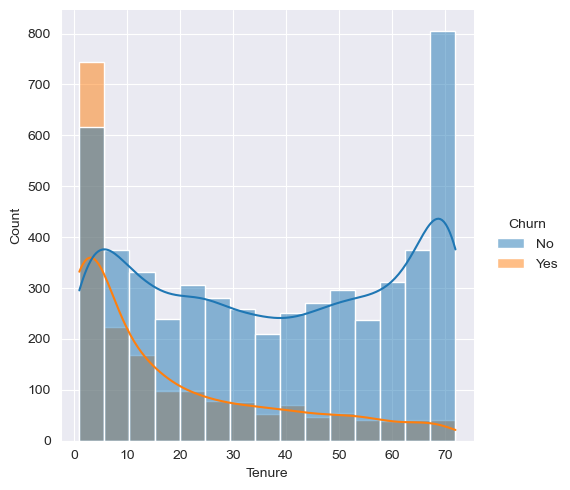

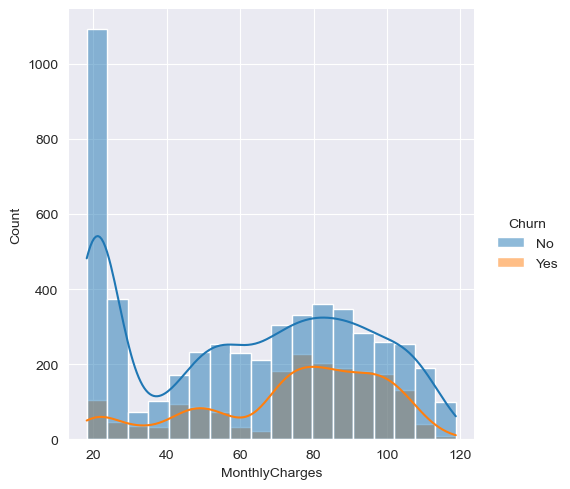

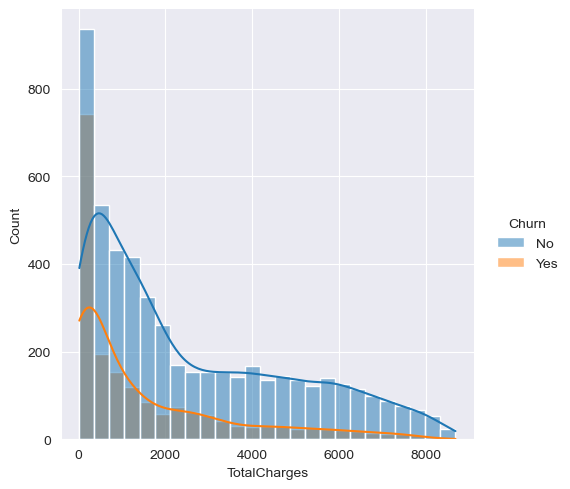

In [28]:
#Visualise the relationship between the numerical features and target
plt.figure()
for col in numerical_columns:
    sns.displot(data= work_df, x=col, kde= True, hue= target_name)
plt.show()

<Figure size 640x480 with 0 Axes>

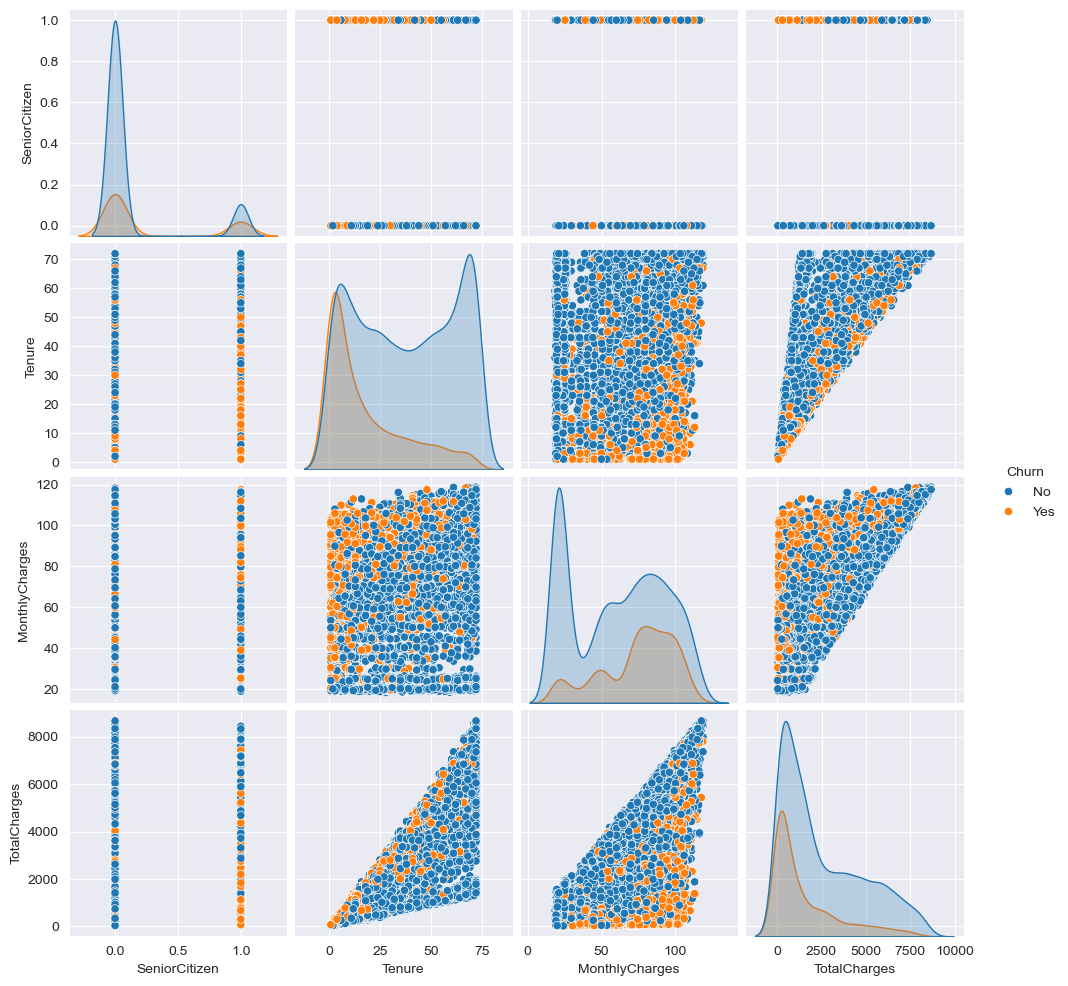

In [29]:
plt.figure()
sns.pairplot(data=work_df, hue= target_name)
plt.show()

<Figure size 640x480 with 0 Axes>

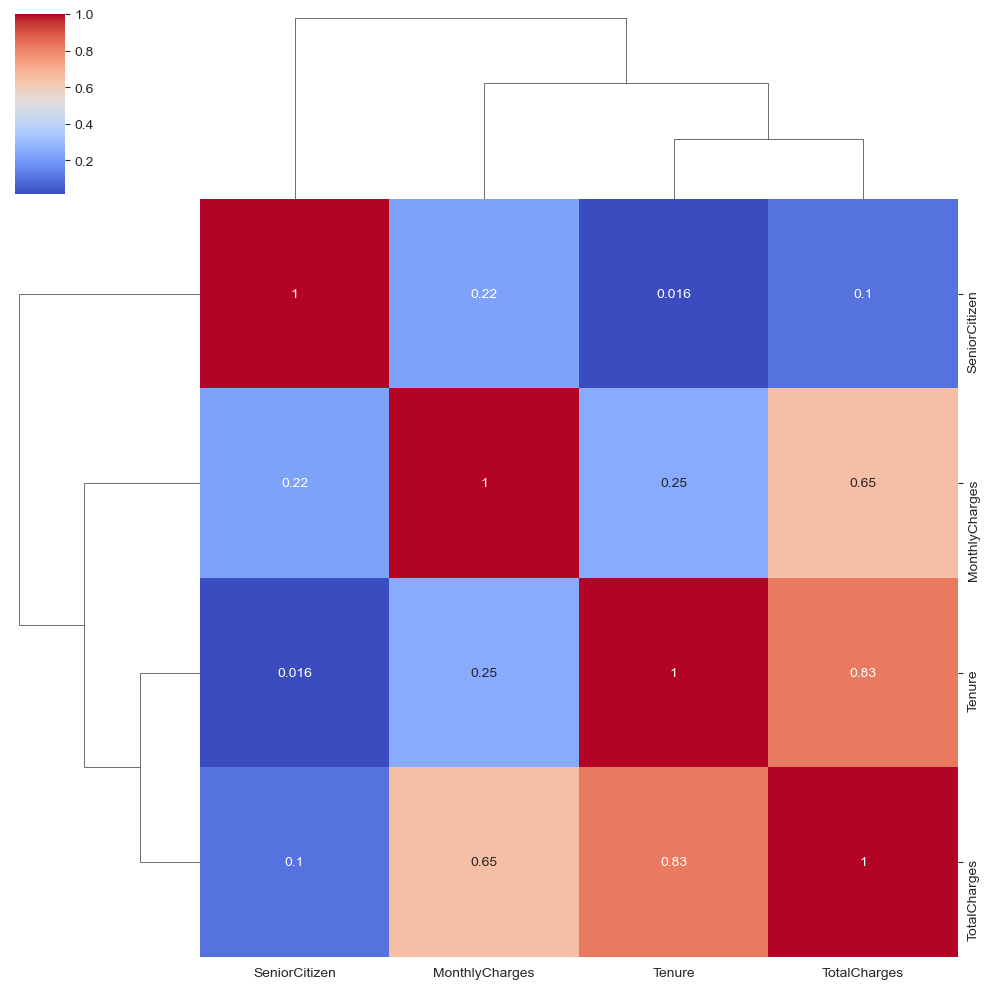

In [30]:
#Visualise relationship between numerical features
plt.figure()
sns.clustermap(work_df[numerical_columns].corr(), cmap= 'coolwarm', annot= True)
plt.show()

In [31]:
#NaN Analysis
work_df[work_df == " "].notna().sum()

customerID          0
Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [32]:
work_df.isna().sum()

customerID          0
Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [33]:
#Identity the outliers: Interquartile Range (IQR) Method
for col in numerical_columns:

    #"SeniorCitizen" value are binary, so the IQR Method is not adapted.
    if col == "SeniorCitizen":
        continue

    q1 = np.quantile(work_df[col], 0.25)
    q3 = np.quantile(work_df[col], 0.75)
    IQR = q3 - q1
    lower_bound = q1 - 1.5 * IQR
    upper_bound = q3 + 1.5 * IQR
    outliers = [x for x in work_df[col] if (x < lower_bound) or (x > upper_bound)]

    print(f"{col} Outliers: {outliers}")


Tenure Outliers: []
MonthlyCharges Outliers: []
TotalCharges Outliers: []


In [34]:
#Summarise the deep analysis
work_df.describe()

,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


## III.Data Preprocessing

In [35]:
#Start from clean dataframe
preprocess_df = df.copy()
preprocess_df

,customerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Monthly,Yes,Manual,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Manual,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Monthly,Yes,Manual,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Monthly,Yes,Manual,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Manual,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No,DSL,Yes,...,No,No,No,No,Monthly,Yes,Manual,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Monthly,Yes,Manual,74.40,306.6,Yes


### Drop Missing Values

In [36]:
#Drop missing values
modify_feat = "TotalCharges"
preprocess_df.drop(labels= preprocess_df[preprocess_df[modify_feat] == " "].index, axis= 0, inplace= True)

In [37]:
#Convert the feature "TotalCharges".
preprocess_df[modify_feat]= preprocess_df[modify_feat].map(lambda x: float(x))
print(preprocess_df.dtypes)

customerID              str
Gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
Tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


In [38]:
#Retreive the features
X = preprocess_df.drop(unnecessary_columns, axis=1)
X

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Monthly,Yes,Manual,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Manual,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Monthly,Yes,Manual,53.85,108.15
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Monthly,Yes,Manual,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Manual,84.80,1990.50
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90
7040,Female,0,Yes,Yes,11,No,No,DSL,Yes,No,No,No,No,No,Monthly,Yes,Manual,29.60,346.45
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Monthly,Yes,Manual,74.40,306.60


### Label Target

In [39]:
#Retrieve Target
target_sr = preprocess_df[target_name]
print(f"Target:\n{target_sr}")

Target:
0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 7032, dtype: str


In [40]:
#Label Target
label_encoder  = LabelEncoder()
y = label_encoder.fit_transform(target_sr)
print(f"y: {y}")

y: [0 0 1 ... 0 1 0]


In [41]:
#Conversion table
for val in np.unique(y):
    print(f"{val} --> {label_encoder.inverse_transform([val])[0]}")

0 --> No
1 --> Yes


### Train/Test Split

In [42]:
#Split Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, stratify= y,random_state= 15)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (5625, 19), y_train: (5625,)
X_test: (1407, 19), y_test: (1407,)


In [43]:
#Check the target distribution
for name, data in [ ("y_train", y_train), ("y_test", y_test)]:
    unique, counts = np.unique(data, return_counts=True)
    total = sum(counts)
    print(f"{name} data distribution: {total}")
    print(f"\t{unique[0]} -> {counts[0]/total * 100:.2f}%")
    print(f"\t{unique[1]} -> {counts[1]/total * 100:.2f}%")
# print(f"y_train data distribution: {}")

y_train data distribution: 5625
	0 -> 73.42%
	1 -> 26.58%
y_test data distribution: 1407
	0 -> 73.42%
	1 -> 26.58%


### Encoder Transformer

In [44]:
#Encode
categorial_transformer = make_column_selector(dtype_include= np.object_)
categorial_transformer

### Standardise Transformer

In [45]:
#Standardise
numerical_transformer = make_column_selector(dtype_include= np.number)
numerical_transformer

### Preprocessor Transformer

In [46]:
#Associate transformer to features
preprocessor = ColumnTransformer(
    transformers=[
        ("Num", StandardScaler(), numerical_transformer),
        ("Cat", OrdinalEncoder(), categorial_transformer),
    ]
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Num', ...), ('Cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

##  IV.Modelling

*   Define the evaluation function
*   Train various model
     - Create different model (Gauss, KNeighors, SVM, Decision Tree, RandomForest [Bagging], AdaBoost or GradientBoosting [Boosting], Artificial Neural Network).
    - Select the most promising model (KNeighors, SVM, AdaBoost, GradientBoosting, Artificial Neural Network).
*   Optimise the model (GridSearchCV)
*   Analyse error and modify the pre-processing to achieve better performance.
*   Learning Curve and Decision from those performances.

**Conclusion:**



In [47]:
#Create Machine Learning Model

#Parameters
ml_names, ml_model = [], []

#Names
ml_names = ["Gauss", "K-Nearest Neighbors", "Support Vector Machine", "Decision Tree", "Random Forest",
            "AdaBoost", "GradientBoosting", "Artificial Neural Network"]
#Models
gauss             = GaussianNB()
knn               = KNeighborsClassifier(n_neighbors= 5)
svc               = SVC(random_state= 15, probability= True)
tree              = DecisionTreeClassifier(random_state= 15)
forest            = RandomForestClassifier(random_state= 15)
adaboost          = AdaBoostClassifier(random_state= 15)
gradient_boosting = GradientBoostingClassifier(random_state= 15)
ann               = MLPClassifier(random_state= 15)

In [48]:
#Create Evaluation Function
def evaluation(model, name: str= None):

    #Display model name
    print(f"Evaluating {name}")

    #Train the model
    model.fit(X_train, y_train)
    #Predict the output
    y_pred = model.predict(X_test)

    #Visualise the confusion matrix and classification report
    print(classification_report(y_test, y_pred))

    plt.figure()
    sns.heatmap(confusion_matrix(y_test, y_pred), annot= True, fmt= 'g',)
    plt.show()

    #Learning Curve to visualise the system perform
    N, train_score, val_score = learning_curve(model,
                                               X_train,
                                               y_train,
                                               train_sizes= np.linspace(0.1, 1.0, 10),
                                               cv= 5,
                                               scoring= "recall",
    )
    plt.figure()
    plt.plot(N, train_score.mean(axis= 1), label="Training Score")
    plt.plot(N, val_score.mean(axis= 1), label="Validation Score")
    plt.legend(loc="best")
    plt.show()
    print()

### Test Model

In [49]:
#Test Evaluation
test_model = make_pipeline(preprocessor, tree)

Evaluating Decision Tree Classifier
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1033
           1       0.51      0.51      0.51       374

    accuracy                           0.74      1407
   macro avg       0.66      0.66      0.66      1407
weighted avg       0.74      0.74      0.74      1407



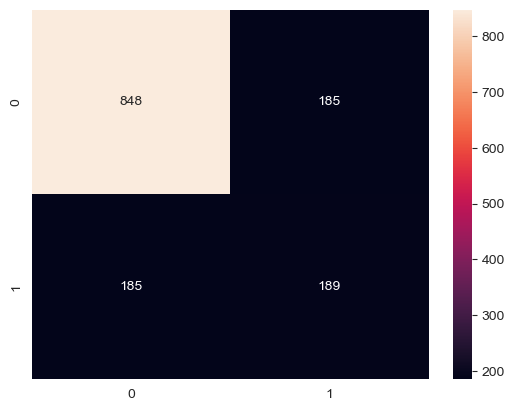

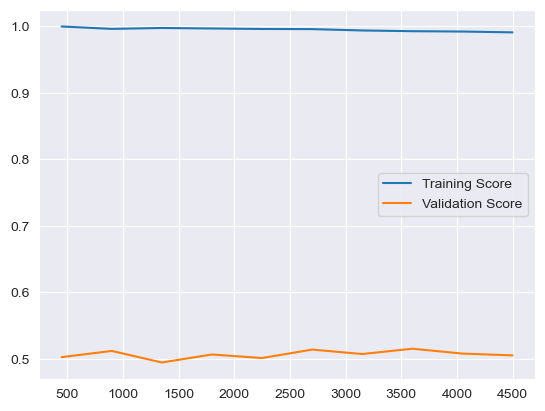

In [50]:
#Evaluate the model
evaluation(test_model, name="Decision Tree Classifier")

In [51]:
#Display Testing Score
print(f"Train Score: {test_model.score(X_train, y_train)}")
print(f"Testing Score: {test_model.score(X_test, y_test)}")

Train Score: 0.9971555555555556
Testing Score: 0.7370291400142146


Testing Model is in clear overffiting with a great training perform (Acc: 1.0) and good testing score (Acc: 0.74)

## V.Features Selection

### Features weight

In [52]:
#Select the most import feature of the Decision Tree model
features_weight = pd.DataFrame(test_model.named_steps["decisiontreeclassifier"].feature_importances_, index= X.columns)
features_weight

,0
Gender,0.012673
SeniorCitizen,0.125115
Partner,0.227990
Dependents,0.225713
Tenure,0.023466
PhoneService,0.019771
MultipleLines,0.017486
InternetService,0.002405
OnlineSecurity,0.023768
OnlineBackup,0.012888


<Figure size 1200x1000 with 0 Axes>

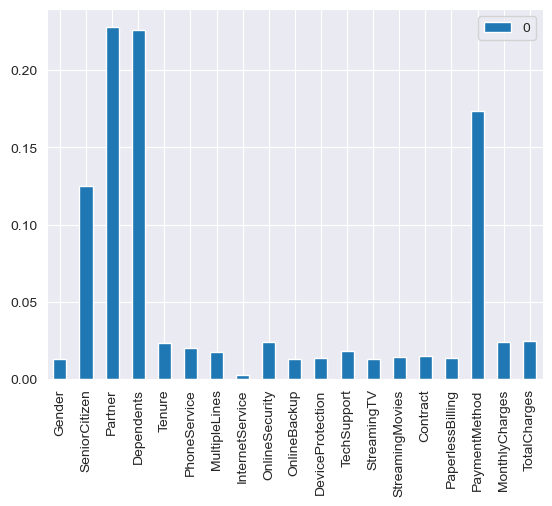

In [53]:
#Visualise Features Weight
plt.figure(figsize= (12,10))
features_weight.plot.bar()
plt.show()

The most influence features:

    - Partner (0.235594)
    - Dependents (0.215887)
    - PaymentMethod (0.167654)
    - SenoirCittizen (0.119171)

A threshold of acceptable weight for the features must be defined --> 0.015

In [54]:
#Display the features
features_weight[features_weight >= 0.015]

,0
Gender,NaN
SeniorCitizen,0.125115
Partner,0.227990
Dependents,0.225713
Tenure,0.023466
PhoneService,0.019771
MultipleLines,0.017486
InternetService,NaN
OnlineSecurity,0.023768
OnlineBackup,NaN


Select features:

    - Categorial: Gender, Partner, Dependents, PhoneService, MultipleLines, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, PaymentMethod.
    - Numerical: SeniorCitizen, Tenure, MonthlyCarges, TotalCharges.

### Features encoding and scaling

In [55]:
num_col, cat_col = [], []
for col in X_train.columns:
    if X_train.dtypes[col] in ["object", "string"]:
        print(f"Column {col}: {X_train.dtypes[col]}")


Column Gender: str
Column Partner: str
Column Dependents: str
Column PhoneService: str
Column MultipleLines: str
Column InternetService: str
Column OnlineSecurity: str
Column OnlineBackup: str
Column DeviceProtection: str
Column TechSupport: str
Column StreamingTV: str
Column StreamingMovies: str
Column Contract: str
Column PaperlessBilling: str
Column PaymentMethod: str


In [56]:
#Retrieve numerical and categorical columns list
#Parameter
num_col, cat_col = [], []
for col in X_train.columns:
    if X_train.dtypes[col] in ["object", "string"]:
        cat_col.append(col)
    else:
        num_col.append(col)

print(f"Numerical columns: {num_col}")
print(f"Categorical columns: {cat_col}")

Numerical columns: ['SeniorCitizen', 'Tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['Gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [57]:
#Encode the categorical columns
ord_encoder = OrdinalEncoder()
X_train_cat_encoded = pd.DataFrame(ord_encoder.fit_transform(X_train[cat_col]), columns = cat_col)
X_train_cat_encoded

,Gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
1,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
2,1.0,1.0,1.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
3,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,2.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5620,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,2.0
5621,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0
5622,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
5623,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,2.0,1.0,1.0


In [58]:
#Standardise the numerical columns
std_scaler = StandardScaler()
X_train_num_scaled = pd.DataFrame(std_scaler.fit_transform(X_train[num_col]), columns = num_col)
X_train_num_scaled

,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges
0,-0.438455,-1.268300,0.216862,-0.967621
1,-0.438455,-0.577302,0.846731,-0.323584
2,-0.438455,0.967281,-1.337814,-0.365908
3,-0.438455,1.617632,0.491805,1.545348
4,-0.438455,-1.146359,-0.544646,-0.909619
...,...,...,...,...
5620,-0.438455,-0.943124,0.721757,-0.658307
5621,-0.438455,-0.699243,-1.467787,-0.868179
5622,2.280738,1.495691,0.676767,1.559678
5623,-0.438455,1.576985,0.726756,1.730543


In [59]:
X_train_encoded = pd.concat([X_train_cat_encoded, X_train_num_scaled], axis= 1)
X_train_encoded

,Gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges
0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,-0.438455,-1.268300,0.216862,-0.967621
1,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,-0.438455,-0.577302,0.846731,-0.323584
2,1.0,1.0,1.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,-0.438455,0.967281,-1.337814,-0.365908
3,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,2.0,1.0,0.0,-0.438455,1.617632,0.491805,1.545348
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,2.0,-0.438455,-1.146359,-0.544646,-0.909619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5620,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,2.0,-0.438455,-0.943124,0.721757,-0.658307
5621,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,-0.438455,-0.699243,-1.467787,-0.868179
5622,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.280738,1.495691,0.676767,1.559678
5623,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,2.0,1.0,1.0,-0.438455,1.576985,0.726756,1.730543


### Variance Threshold Test

In [60]:
#Variance Threshold
threshold = 0.20
selector_var = VarianceThreshold(threshold= threshold)
selector_var.fit(X_train_encoded)
X_train_encoded.columns[selector_var.get_support()]

Index(['Gender', 'Partner', 'Dependents', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'SeniorCitizen', 'Tenure', 'MonthlyCharges',
       'TotalCharges'],
      dtype='str')

All the features listed have a variance superior or equal at 0.20.
And of the most influence features are present (Partner, Dependents, PaymentMethod, SeniorCitizen, Tenure and TotalCharges).

### Recursive Features Elimination Cross Validation Test

In [61]:
#Recursive Features Elimination Cross Validation
selector_rfecv = RFECV(DecisionTreeClassifier(random_state= 15), step= 0.2, n_jobs= -1, scoring= 'roc_auc', cv= 5, min_features_to_select= 6)
selector_rfecv.fit(X_train_encoded, y_train)

,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,DecisionTreeC...ndom_state=15)
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",0.2
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",6
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",5
,"scoring scoring: str or callable, default=NoneScoring method to evaluate the :class:`RFE` selectors' performance. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",'roc_auc'
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"n_jobs n_jobs: int or None, default=NoneNumber of cores to run in parallel while fitting across folds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",-1
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance.For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None


In [62]:
for i, feat in zip(selector_rfecv.ranking_, X_train_encoded.columns):
    print(f"Feature {i}: {feat}")

Feature 1: Gender
Feature 2: Partner
Feature 4: Dependents
Feature 5: PhoneService
Feature 2: MultipleLines
Feature 5: InternetService
Feature 4: OnlineSecurity
Feature 3: OnlineBackup
Feature 4: DeviceProtection
Feature 3: TechSupport
Feature 3: StreamingTV
Feature 5: StreamingMovies
Feature 1: Contract
Feature 1: PaperlessBilling
Feature 1: PaymentMethod
Feature 2: SeniorCitizen
Feature 1: Tenure
Feature 1: MonthlyCharges
Feature 1: TotalCharges


In [63]:
#Retrieve the RFECV selected features
rfecv_selected_features = selector_rfecv.get_feature_names_out()

#Display the RFECV selected features
print(" RFECV Selected Features: ", rfecv_selected_features)

 RFECV Selected Features:  ['Gender' 'Contract' 'PaperlessBilling' 'PaymentMethod' 'Tenure'
 'MonthlyCharges' 'TotalCharges']


This is a confirmation that the features ('Gender', 'Partner', 'Dependents', 'MultipleLines','InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen', 'Tenure', 'MonthlyCharges', 'TotalCharges') are listed into the most influent ones.

### Selected Features

The features present in the various features selection methods are:

    - Categorial: Gender, Partner, Dependents, MultipleLines, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, PaymentMethod.
    - Numerical: SeniorCitizen, Tenure, MonthlyCharges, TotalCharges.

In [64]:
#Modify the training and testing set
selected_features = ["Gender", "Partner", "Dependents", "MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "PaymentMethod", "SeniorCitizen", "Tenure", "MonthlyCharges", "TotalCharges"]
X = X[selected_features]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, stratify= y, random_state= 15)

#Display the new training and testing set shape
print(f"Training features data shape: {X_train.shape}")
print(f"Test features data shape: {X_test.shape}")
print(f"Training target data shape: {y_train.shape}")
print(f"Test target data shape: {y_test.shape}")

Training features data shape: (5625, 13)
Test features data shape: (1407, 13)
Training target data shape: (5625,)
Test target data shape: (1407,)


## VI.Model Evaluation

In [89]:
#Redefine the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("Num", StandardScaler(), ["Tenure", "MonthlyCharges", "TotalCharges"]),
        ("Cat", OrdinalEncoder(), ["Gender", "Partner", "Dependents", "MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "PaymentMethod"]),
    ]
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Num', ...), ('Cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

Evaluating Gauss
              precision    recall  f1-score   support

           0       0.85      0.77      0.81      1033
           1       0.49      0.61      0.55       374

    accuracy                           0.73      1407
   macro avg       0.67      0.69      0.68      1407
weighted avg       0.75      0.73      0.74      1407



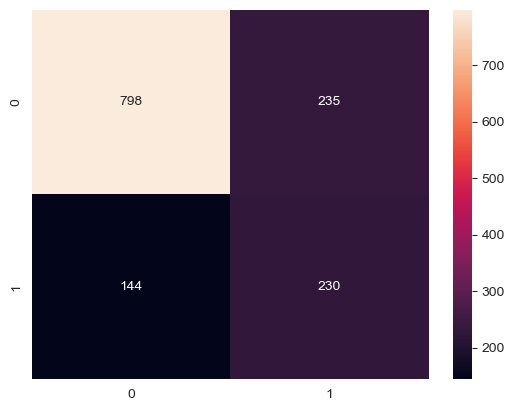

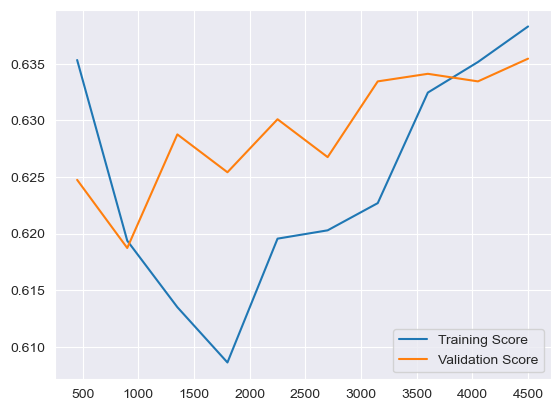


Evaluating K-Nearest Neighbors
              precision    recall  f1-score   support

           0       0.83      0.86      0.84      1033
           1       0.57      0.50      0.53       374

    accuracy                           0.77      1407
   macro avg       0.70      0.68      0.69      1407
weighted avg       0.76      0.77      0.76      1407



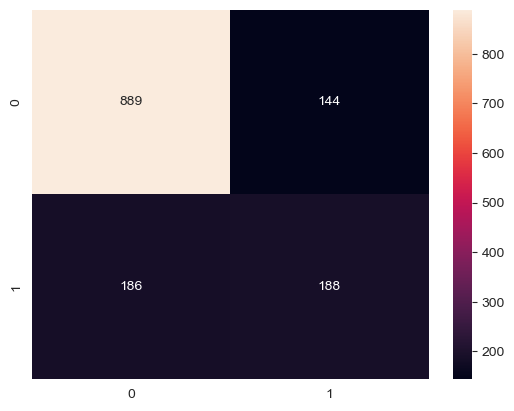

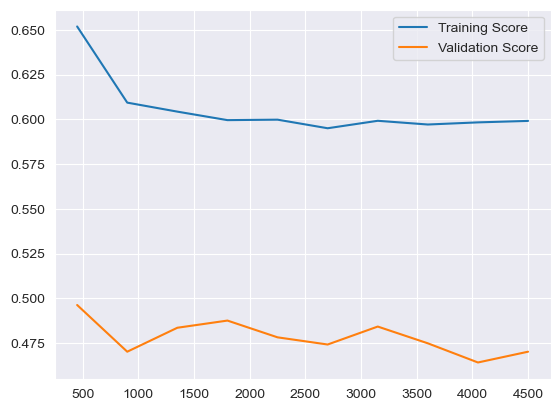


Evaluating Support Vector Machine
              precision    recall  f1-score   support

           0       0.82      0.94      0.88      1033
           1       0.73      0.42      0.54       374

    accuracy                           0.81      1407
   macro avg       0.78      0.68      0.71      1407
weighted avg       0.80      0.81      0.79      1407



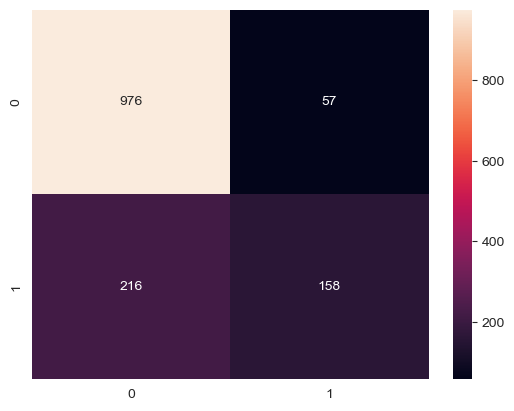

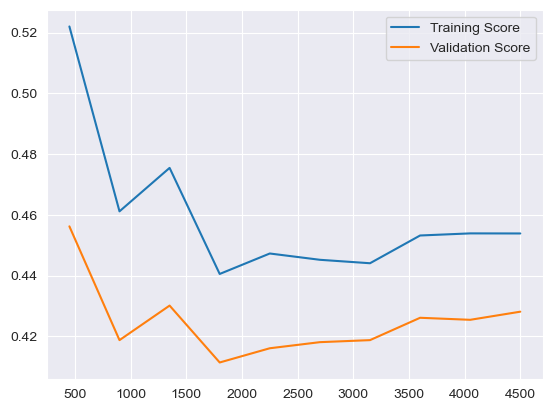


Evaluating Decision Tree
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1033
           1       0.47      0.48      0.47       374

    accuracy                           0.72      1407
   macro avg       0.64      0.64      0.64      1407
weighted avg       0.72      0.72      0.72      1407



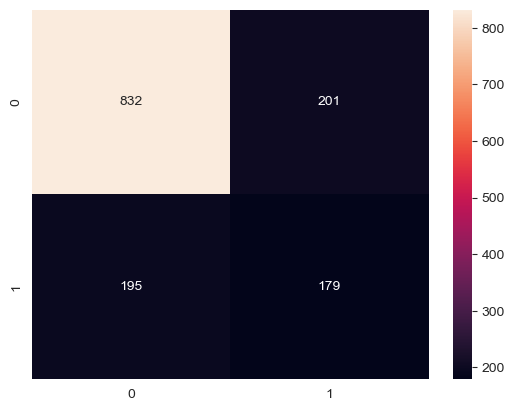

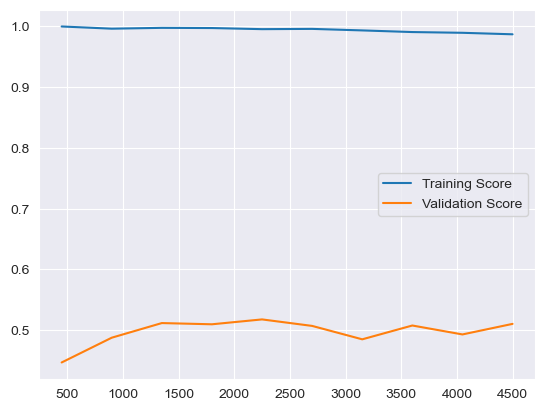


Evaluating Random Forest
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.63      0.45      0.53       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.77      1407



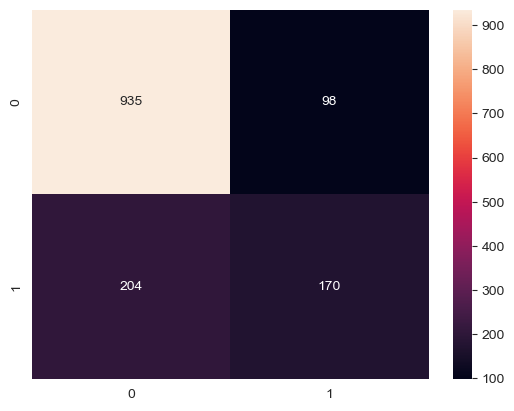

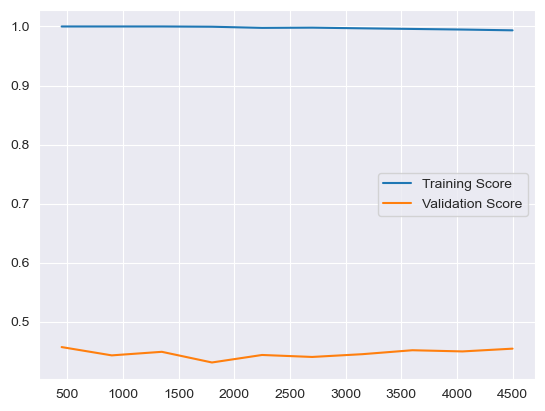


Evaluating AdaBoost
              precision    recall  f1-score   support

           0       0.82      0.93      0.87      1033
           1       0.68      0.44      0.53       374

    accuracy                           0.80      1407
   macro avg       0.75      0.68      0.70      1407
weighted avg       0.78      0.80      0.78      1407



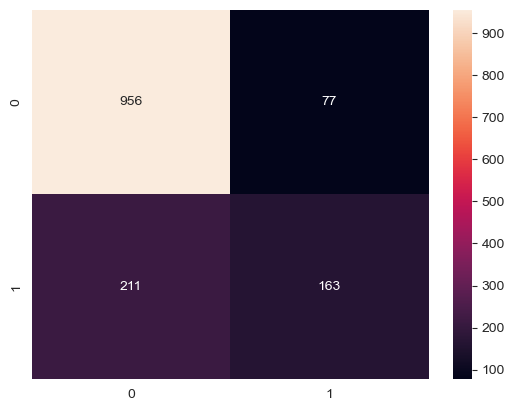

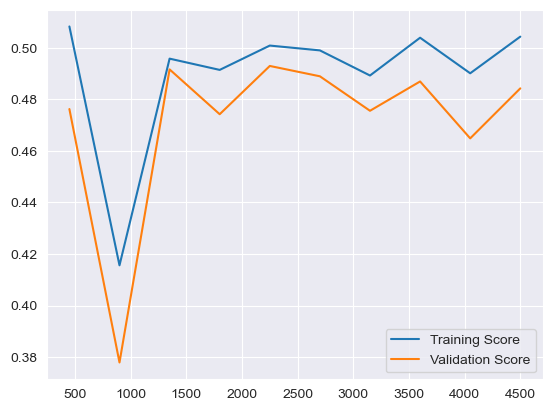


Evaluating GradientBoosting
              precision    recall  f1-score   support

           0       0.83      0.91      0.86      1033
           1       0.64      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



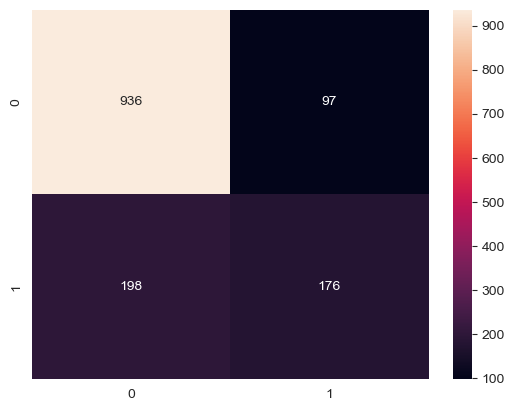

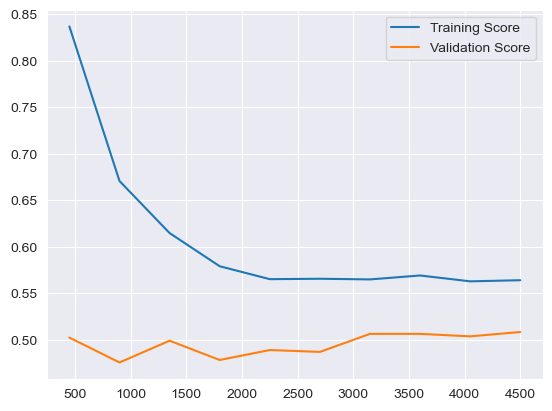


Evaluating Artificial Neural Network
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.67      0.47      0.55       374

    accuracy                           0.80      1407
   macro avg       0.75      0.69      0.71      1407
weighted avg       0.78      0.80      0.78      1407



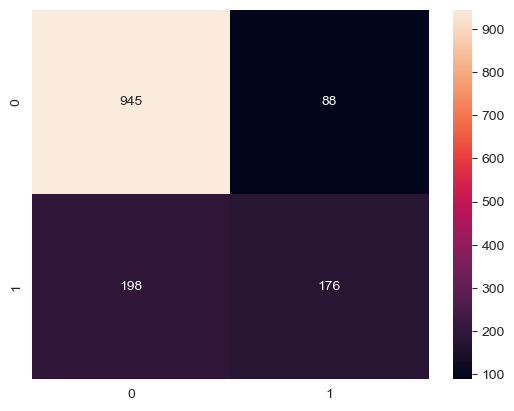

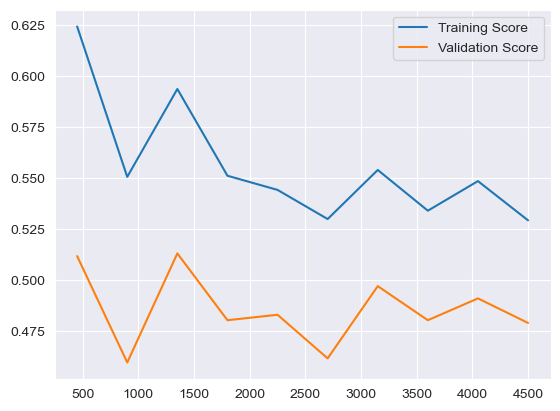

In [66]:
#Create Models Pipeline

#Ignore all warnings
warnings.filterwarnings("ignore")

gauss_model = make_pipeline(preprocessor, gauss)
knn_model = make_pipeline(preprocessor, knn)
svc_model = make_pipeline(preprocessor, svc)
tree_model = make_pipeline(preprocessor, tree)
forest_model = make_pipeline(preprocessor, forest)
adaboost_model = make_pipeline(preprocessor, adaboost)
gradient_boosting_model = make_pipeline(preprocessor, gradient_boosting)
ann_model = make_pipeline(preprocessor, ann)

#Regroup the model
ml_model = [gauss_model, knn_model, svc_model, tree_model, forest_model, adaboost_model, gradient_boosting_model, ann_model]

for name, model in zip(ml_names, ml_model):
    evaluation(model, name)


The best performing model:

        - Random Forest Acc: 0.79
        - Support Vector Machine Acc: 0.81
        - AdaBoost Acc: 0.80
        - GradientBoosting Acc: 0.79
        - Artificial Neural Network Acc: 0.80

## VII.Hyperparameter Tuning (GridSearchCV)

In [67]:
#Retrieve the model identification name inside the pipeline
for name , model in zip(ml_names, ml_model):
  print(f"{name:-<50} {model} ")
  print()

Gauss--------------------------------------------- Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('Num', StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x000001488B9A8050>),
                                                 ('Cat', OrdinalEncoder(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x000001488B9AB4D0>)])),
                ('gaussiannb', GaussianNB())]) 

K-Nearest Neighbors------------------------------- Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('Num', StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x000001488B9A8050>),
                                                 ('Cat', OrdinalEncoder(),
                                                  

In [68]:
#Create various model parameters to optimise

#Random Forest
rf_param_prefix = "randomforestclassifier__"
rf_params_grid = {
    rf_param_prefix+"n_estimators": [50, 100, 150, 200],
    rf_param_prefix+"max_depth": [10, 20, None],
    rf_param_prefix+"min_samples_split": [2, 5, None],
    rf_param_prefix+"min_samples_leaf": [1, 2, None],
    rf_param_prefix+"criterion": ['gini', 'entropy'],
}


#Support Vector Machine
svc_param_prefix = "svc__"
svc_params_grid = {
    svc_param_prefix+"C": [0.1, 1, 10, 100, 1000],
    svc_param_prefix+"kernel": ["linear", "poly", "rbf", "sigmoid"],
    svc_param_prefix+"gamma": [1e-2, 1e-3, 1e-4],
    svc_param_prefix+"degree": [1, 3, 5, 7],
}

#AdaBoost
adaboost_param_prefix = "adaboostclassifier__"
adaboost_params_grid = {
    adaboost_param_prefix+"learning_rate": [0.1, 0.01, 0.001, 0.0001],
    adaboost_param_prefix+"n_estimators": [10, 20, 50, 100, 150, 200],
}

#GradientBoosting
gradient_boosting_param_prefix = "gradientboostingclassifier__"
gradient_boosting_params_grid = {
    gradient_boosting_param_prefix+"n_estimators": [10, 20, 50, 100, 150, 200],
    gradient_boosting_param_prefix+"learning_rate": [0.1, 0.01, 0.001, 0.0001],
}

#Artificial Neural Network
ann_model_param_prefix = "mlpclassifier__"
ann_model_params_grid = {
    ann_model_param_prefix+"hidden_layer_sizes": [100, 200, 300, 400, 500],
    ann_model_param_prefix+"activation": ["relu", "identity", "logistic", "tanh"],
    ann_model_param_prefix+"solver": ["sgd", "adam", "lbfgs"],
    ann_model_param_prefix+"learning_rate": ["constant", "invscaling", "adaptive"],
}


In [69]:
#Create the various model grid

#Parameters
grid_names = ["Random Forest", "Support Vector Machine", "AdaBoost", "Gradient Boosting", "Artificial Neural Network"]
grid_models = [forest_model, svc_model, adaboost_model, gradient_boosting_model, ann_model,]
grid_params = [rf_params_grid, svc_params_grid, adaboost_params_grid, gradient_boosting_params_grid, ann_model_params_grid]

In [70]:
#Plot Learning Curve Function
def plot_learning_curve(name: str, estimator):
    print(name)
    #Learning Curve to visualise the system perform
    N, train_score, val_score = learning_curve(estimator,
                                               X_train,
                                               y_train,
                                               train_sizes= np.linspace(0.1, 1.0, 10),
                                               cv= 5,
                                               scoring= "recall",
    )

    plt.figure()
    plt.title("Learning Curve")
    plt.plot(N, train_score.mean(axis= 1), label="Training Score")
    plt.plot(N, val_score.mean(axis= 1), label="Validation Score")
    plt.legend(loc="best")
    plt.show()
    print()

In [71]:
#Create Grid Model Evaluation Function
def grid_evaluation(name: str, model, param:dict):

    #Create the estimator
    model_grid = GridSearchCV(model,
                               param_grid= param,
                               scoring= "recall",
                               cv= 5, )

    #Train the estimator
    model_grid.fit(X_train, y_train)

    #Display Estimator Hyperparameter
    print(f"{name:-<50} {model_grid.best_params_}")
    print(f"{name:-<50} {model_grid.best_score_}")

    #Estimator Prediction
    y_pred = model_grid.predict(X_test)

    #Display Estimator Performance
    print(f"Recall: {recall_score(y_test, y_pred)}")
    print(f"Precision: {precision_score(y_test, y_pred)}")
    print(f"F1 Score: {f1_score(y_test, y_pred)}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_pred)}")
    print()

    #Display the Classification report
    print(f"{name}:\n"
          f"{classification_report(y_test, y_pred)}")
    print()

    return model_grid.best_estimator_


Random Forest------------------------------------- {'randomforestclassifier__criterion': 'gini', 'randomforestclassifier__max_depth': 20, 'randomforestclassifier__min_samples_leaf': 2, 'randomforestclassifier__min_samples_split': 5, 'randomforestclassifier__n_estimators': 150}
Random Forest------------------------------------- 0.4809364548494983
Recall: 0.46524064171123
Precision: 0.6492537313432836
F1 Score: 0.5420560747663551
ROC-AUC: 0.6871217729369316

Random Forest:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.65      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407


Random Forest


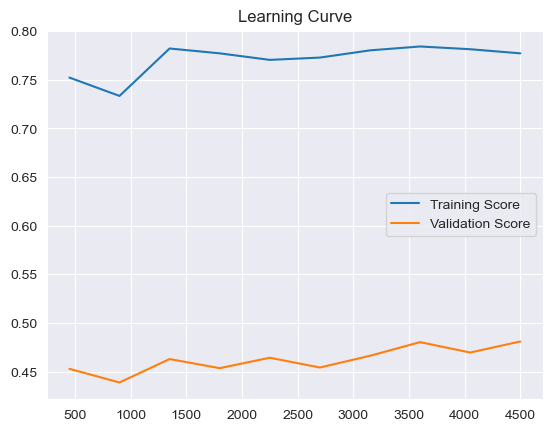


Support Vector Machine---------------------------- {'svc__C': 10, 'svc__degree': 1, 'svc__gamma': 0.01, 'svc__kernel': 'sigmoid'}
Support Vector Machine---------------------------- 0.5103678929765886
Recall: 0.5133689839572193
Precision: 0.6689895470383276
F1 Score: 0.5809379727685325
ROC-AUC: 0.7107019169544083

Support Vector Machine:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1033
           1       0.67      0.51      0.58       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407


Support Vector Machine


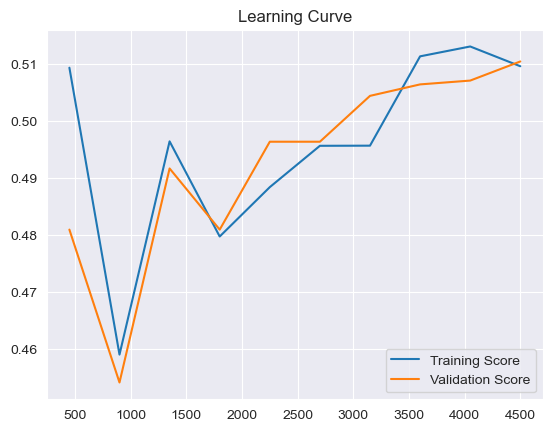


AdaBoost------------------------------------------ {'adaboostclassifier__learning_rate': 0.1, 'adaboostclassifier__n_estimators': 200}
AdaBoost------------------------------------------ 0.3010033444816053
Recall: 0.24598930481283424
Precision: 0.7603305785123967
F1 Score: 0.3717171717171717
ROC-AUC: 0.6089578663463978

AdaBoost:
              precision    recall  f1-score   support

           0       0.78      0.97      0.87      1033
           1       0.76      0.25      0.37       374

    accuracy                           0.78      1407
   macro avg       0.77      0.61      0.62      1407
weighted avg       0.78      0.78      0.73      1407


AdaBoost


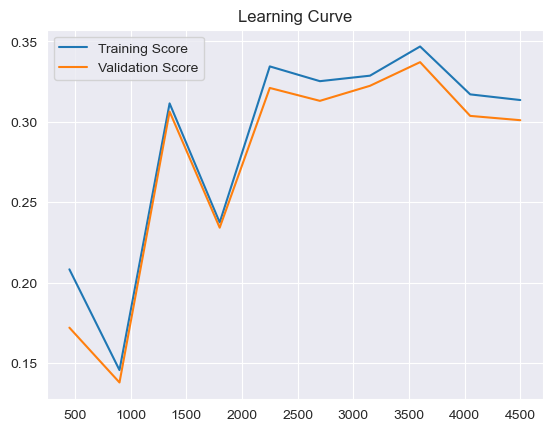


Gradient Boosting--------------------------------- {'gradientboostingclassifier__learning_rate': 0.1, 'gradientboostingclassifier__n_estimators': 150}
Gradient Boosting--------------------------------- 0.5150501672240803
Recall: 0.47058823529411764
Precision: 0.6470588235294118
F1 Score: 0.544891640866873
ROC-AUC: 0.6888275155173396

Gradient Boosting:
              precision    recall  f1-score   support

           0       0.83      0.91      0.86      1033
           1       0.65      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407


Gradient Boosting


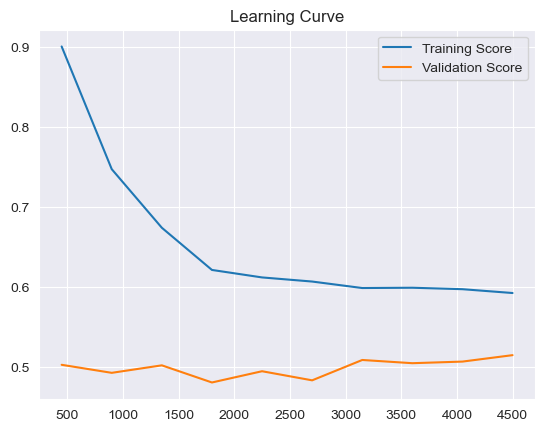


Artificial Neural Network------------------------- {'mlpclassifier__activation': 'logistic', 'mlpclassifier__hidden_layer_sizes': 300, 'mlpclassifier__learning_rate': 'constant', 'mlpclassifier__solver': 'adam'}
Artificial Neural Network------------------------- 0.5250836120401338
Recall: 0.40106951871657753
Precision: 0.7246376811594203
F1 Score: 0.5163511187607573
ROC-AUC: 0.672945214343768

Artificial Neural Network:
              precision    recall  f1-score   support

           0       0.81      0.94      0.87      1033
           1       0.72      0.40      0.52       374

    accuracy                           0.80      1407
   macro avg       0.77      0.67      0.70      1407
weighted avg       0.79      0.80      0.78      1407


Artificial Neural Network


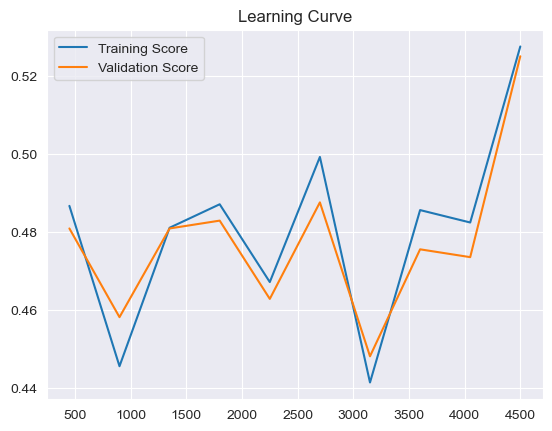

In [72]:
#Evaluate and retrieve the model best estimator
best_estimators = {}
for name, model, param in zip(grid_names, grid_models, grid_params):
    model = grid_evaluation(name, model, param)
    plot_learning_curve(name, model)
    best_estimators[name] = model

The model with the best performance are:

        - Support Vector Classifier (Accuracy: 0.510, Recall: 0.465, Precision: 0.649, F1 Score: 0.542,ROC-AUC: 0.687)
        has the best performance with no variance (overffiting) but does have some biais (underfitting).
        - Artificial Neural Network (Accuracy: 0.515, Recall: 0.470, Precision: 0.670, F1 Score: 0.544, ROC-AUC: 0.688)
        has on the best performance with biais and no variance.
        - Gradient Boosting (Accuracy: 0.515, Recall: 0.470, Precision: 0.647, F1 Score: 0.544, ROC-AUC: 0.688)
        has one the best performance with variance and biais.


## VIII.Precision Recall Curve

In [73]:
#Plot Precision Recall Curve Function
def precision_recall_curve_pipeline(name: str, pipeline: Pipeline):
    print(name)

    #Get the Classifier inside your pipeline
    model = pipeline.steps[-1][1]

    #Transformed (preprocess) data
    X_test_transformed = pipeline.steps[0][1].transform(X_test)

    # Use decision_function if available, else use predict_proba
    if hasattr(model, "decision_function"):
        model_predict = model.decision_function(X_test_transformed)
    else:
        model_predict = model.predict_proba(X_test_transformed)[:, 1]

    #Retrieve the precision, recall and threshold
    precision , recall, threshold = precision_recall_curve(y_test, model_predict)

    #Visualise the precision and recall in function of the threshold
    plt.figure()
    plt.plot(threshold, precision[:-1], label="Precision")
    plt.plot(threshold, recall[: -1], label="Recall")
    plt.legend()
    plt.show()

    print()


Support Vector Machine


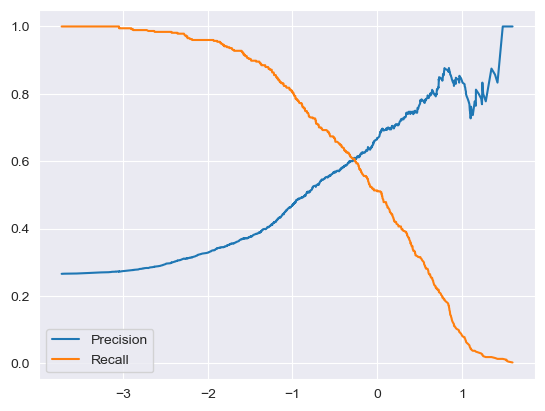


Gradient Boosting


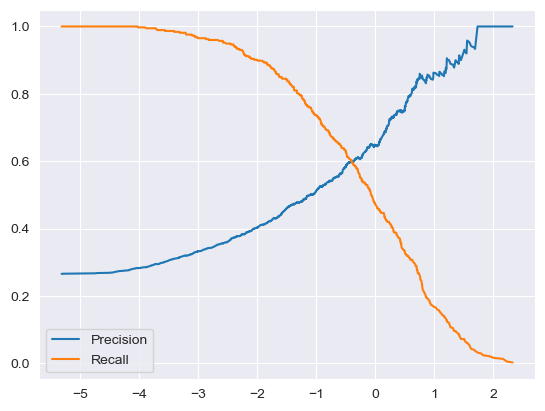


Artificial Neural Network


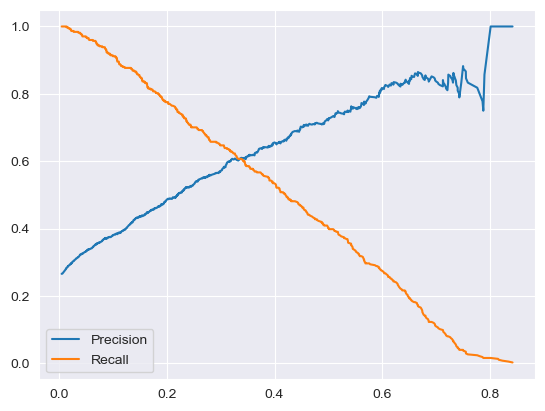

In [74]:
#Display the Precision Recall Curve
names = ["Support Vector Machine", "Gradient Boosting", "Artificial Neural Network"]
pipelines = [best_estimators[name] for name in names]
for name, pipeline in zip(names, pipelines):
    precision_recall_curve_pipeline(name, pipeline)

Adjusting the classification threshold allows for the optimization of recall, though this typically results in a corresponding decrease in precision, and overall accuracy. Consequently, a strategic trade-off between these metrics must be established for each model.

    - SVC threshold: -1.5
    - Gradient Boosting: -2.5
    - Aritficial Neural Network: 0.11


### Threshold

In [75]:
#Create model with threshold
def threshold_pipeline(name, pipeline: Pipeline, threshold: float = 0.0):
    print(name)

    #Get the Classifier inside your pipeline
    model = pipeline.steps[-1][1]

    #Transformed (preprocess) data
    X_test_transformed = pipeline.steps[0][1].transform(X_test)

    # Use decision_function if available, else use predict_proba
    if hasattr(model, "decision_function"):
        model_predict = model.decision_function(X_test_transformed)
    else:
        model_predict = model.predict_proba(X_test_transformed)[:, 1]

    y_pred = [1 if pred >= threshold else 0 for pred in model_predict]

    return y_pred

In [76]:
#Display the Precision Recall Curve
thresholds = [-1.5, -2.5, 0.11]
predictions = {}
for name, pipeline, threshold in zip(names, pipelines, thresholds):
    y_pred = threshold_pipeline(name, pipeline, threshold)
    predictions[name] = y_pred

Support Vector Machine
Gradient Boosting
Artificial Neural Network


In [77]:
#Model Performance Function
def model_performance(name, y_true: list | pd.Series, y_pred: list | pd.Series):
    print(name)
    print(classification_report(y_true, y_pred))
    print(f"Accuracy: {accuracy_score(y_true, y_pred)}")
    print(f"F1      : {f1_score(y_true, y_pred)}")
    print(f"Recall  : {recall_score(y_true, y_pred)}")
    print()

In [78]:
#Display each estimator performance
for name in names:
    y_pred = predictions.get(name)
    model_performance(name, y_test, y_pred)

Support Vector Machine
              precision    recall  f1-score   support

           0       0.93      0.46      0.61      1033
           1       0.38      0.90      0.53       374

    accuracy                           0.58      1407
   macro avg       0.65      0.68      0.57      1407
weighted avg       0.78      0.58      0.59      1407

Accuracy: 0.5756929637526652
F1      : 0.5310290652003142
Recall  : 0.9037433155080213

Gradient Boosting
              precision    recall  f1-score   support

           0       0.95      0.39      0.55      1033
           1       0.36      0.95      0.52       374

    accuracy                           0.54      1407
   macro avg       0.66      0.67      0.54      1407
weighted avg       0.80      0.54      0.54      1407

Accuracy: 0.5380241648898365
F1      : 0.5220588235294118
Recall  : 0.9491978609625669

Artificial Neural Network
              precision    recall  f1-score   support

           0       0.93      0.49      0.64     

The Artificial Neural Network (ANN) emerged as the optimal model, achieving an ideal balance with a 0.10 classification threshold. This configuration yielded 60% accuracy and a high recall of 90%. In contrast, this lower fixed thresholds disproportionately prioritized churn detection at the cost of overall predictive precision.

#### Fixing Threshold

In [79]:
for pipeline in pipelines:
    print(pipeline)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('Num', StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000014886F72E70>),
                                                 ('Cat', OrdinalEncoder(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000014886985E50>)])),
                ('svc',
                 SVC(C=10, degree=1, gamma=0.01, kernel='sigmoid',
                     probability=True, random_state=15))])
Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('Num', StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000014888A5A810>),
                                                 ('Cat', OrdinalEncoder(),
                                                  <

In [80]:
for pipeline in pipelines:
    print(pipeline)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('Num', StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000014886F72E70>),
                                                 ('Cat', OrdinalEncoder(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000014886985E50>)])),
                ('svc',
                 SVC(C=10, degree=1, gamma=0.01, kernel='sigmoid',
                     probability=True, random_state=15))])
Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('Num', StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000014888A5A810>),
                                                 ('Cat', OrdinalEncoder(),
                                                  <

In [90]:
#Fixing Threshold
proba_method = ["decision_function", "decision_function", "predict_proba"]
models_threshold = []
for name, pipeline, threshold, method in zip(names, pipelines, thresholds, proba_method):

    #Create ML model with fix threshold
    model = FixedThresholdClassifier(estimator=pipeline.steps[-1][1],
                                     threshold=threshold,
                                     response_method= method,
                                     )
    #Create the model pipeline
    model_pipeline = make_pipeline(preprocessor, model)

    #Train the model pipeline
    model_pipeline.fit(X_train, y_train)

    #Model prediction
    y_pred = model_pipeline.predict(X_test)

    #Organize the data
    result = {"name": name,
               "pipeline": model_pipeline,
               "threshold": threshold,
              "predictions": y_pred,
            }

    #Display model with threshold performance
    model_performance(name, y_test, y_pred)

    models_threshold.append(result)


Support Vector Machine
              precision    recall  f1-score   support

           0       0.93      0.46      0.61      1033
           1       0.37      0.90      0.53       374

    accuracy                           0.57      1407
   macro avg       0.65      0.68      0.57      1407
weighted avg       0.78      0.57      0.59      1407

Accuracy: 0.574271499644634
F1      : 0.5287175452399685
Recall  : 0.8983957219251337

Gradient Boosting
              precision    recall  f1-score   support

           0       0.95      0.39      0.55      1033
           1       0.36      0.95      0.52       374

    accuracy                           0.54      1407
   macro avg       0.66      0.67      0.53      1407
weighted avg       0.79      0.54      0.54      1407

Accuracy: 0.535181236673774
F1      : 0.5198237885462555
Recall  : 0.946524064171123

Artificial Neural Network
              precision    recall  f1-score   support

           0       0.94      0.43      0.60      10

### Voting Classifier

Beyond single-model optimization, we can improve reliability by implementing a Bagging ensemble. Averaging the predictions from our best-performing models helps smooth out errors, providing a more consistent balance between accuracy and recall.

In [91]:
#Create Bagging Model
pipeline_name = "pipeline"
bagging_model = VotingClassifier(
    estimators=[
        ("Support Vector Machine", models_threshold[0][pipeline_name]),
        ("Gradient Boosting", models_threshold[1][pipeline_name]),
        ("Artificial Neural Network", models_threshold[2][pipeline_name]),
    ],
    voting="hard",
)

#Train the model
bagging_model.fit(X_train, y_train)

#Predict the output
y_pred_bagging = bagging_model.predict(X_test)

model_performance("Bagging Model", y_test, y_pred_bagging)

Bagging Model
              precision    recall  f1-score   support

           0       0.94      0.43      0.59      1033
           1       0.37      0.92      0.53       374

    accuracy                           0.56      1407
   macro avg       0.66      0.68      0.56      1407
weighted avg       0.79      0.56      0.58      1407

Accuracy: 0.5643212508884151
F1      : 0.5295471987720645
Recall  : 0.9224598930481284



The Bagging model was slightly outmatched by an individual classifiers. The Artificial Neural Network (ANN) demonstrated superior performance when utilizing a tuned decision threshold, proving more effective at capturing churn dynamics than the averaged ensemble approach.

### Save Best Model

In [92]:
#Retrieve the model pipeline
mlp_threshold_pipeline = models_threshold[2]["pipeline"]
mlp_threshold_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('fixedthresholdclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Num', ...), ('Cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

In [93]:
#Serialize and save the machine learning model
with open("mlp_threshold_pipeline.pkl", "wb") as file:
    pickle.dump(mlp_threshold_pipeline, file)

## IX.Conclusion

The goal of this project was to develop a machine learning model capable of accurately predicting customer churn and providing actionable insights that support proactive retention strategies. Through comprehensive data preprocessing and model evaluation, we identified the key behavioral and demographic factors associated with churn and built a system that can reliably estimate churn risk at the individual customer level.

Multiple classification algorithms—including Support Vector Machines, Gradient Boosting, and others—were trained and compared using metrics such as precision, recall, F1-score, ROC-AUC, and precision–recall curves. Among the tested models, the Artificial Neural Network (Multi-Layer Perceptron) demonstrated the strongest overall performance, offering a robust balance between predictive accuracy and the ability to capture minority-class churn behavior (recall).

The analysis revealed that variables such as payment method, tenure, service usage patterns, partnership,  monthly and total charges were significant drivers of churn. These insights enable businesses to design targeted retention programs, prioritize high-risk customers, and reduce churn-related revenue loss.

In conclusion, the developed churn prediction model provides a valuable data-driven tool for anticipating customer attrition and informing strategic decision-making. With further enhancements—such as real-time scoring, integration into CRM systems, and monitoring model drift—the solution can evolve into a fully operational customer retention system capable of delivering long-term business impact.